1. Let's assume the experiments in the pre-processing and augmentation, just for gaining insights, not making decisions for the following actual model setup. (Note: can we use this reason? : due to a single seed being used in these entire experiments, not trustworthy enough to make the decision; results done in multiple seeds are reliable to produce the decision) The final model should have no pre-processing and no augmentation. Furthermore, suggest a suitable reason to explain this, and which section needs to be revised to update the previous configuration.
2. Instead of manually inserting the timestamp, help me make a constant or variable so that I can run all cells directly, instead of waiting for the time to generate the timestamp and to put it in. Such as setting TIMESTAMP = timestamp.now()
3. All the experiments in the notebook need to be rerun. Just that some are revised, don't delete all the things
4. Also ensure that the baselines produced are the same across all experiments by using the same and flexible function. Fix the pipeline to share code, not duplicate it: have Section 3.6/3.7's main model training call prepare_and_encode(clean_noise=True, trim_silence=False, augmentation='none') (i.e., the actual winning Stage A config) directly, or at minimum have cell 29 accept the same parameters and apply the identical noise-reduction/trimming logic, so there's one single source of truth for "what does the winning preprocessing configuration actually do," not three.

# Section 0. Setup
- Experiment settings (constants)
- Setup with GPU
- Define the 2 model architectures at the beginning

In [1]:
import os
SEED = 42
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import gc
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, recall_score
from sklearn.utils import class_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
import whisper
from transformers import pipeline
import torch
from collections import defaultdict
from datetime import datetime
import noisereduce as nr
from IPython.display import display
import random

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()


class Config:
    # Data Settings
    DATA_PATH = 'dataset_meld/'
    FILE_PREFIX = 'prepared_'
    SR = 16000
    MAX_DURATION = 3
    MAX_SAMPLES = SR * MAX_DURATION
    
    # Feature Settings
    N_MFCC = 40
    MAX_MFCC_LEN = 94  
    
    # Training Parameters 
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 50
    DROPOUT = 0.3
    
    DEFAULT_CLASSES = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']

def set_all_seeds(seed=SEED):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

print("=== Hyperparameters ===")
for k, v in vars(Config).items():
    if not k.startswith('__'): print(f"{k}: {v}")

c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Hyperparameters ===
DATA_PATH: dataset_meld/
FILE_PREFIX: prepared_
SR: 16000
MAX_DURATION: 3
MAX_SAMPLES: 48000
N_MFCC: 40
MAX_MFCC_LEN: 94
BATCH_SIZE: 32
LEARNING_RATE: 0.001
EPOCHS: 50
DROPOUT: 0.3
DEFAULT_CLASSES: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']


In [2]:
import shutil
import imageio_ffmpeg

# 1. Get the directory where imageio_ffmpeg stores its binary
ffmpeg_bin_dir = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())

# 2. Whisper looks specifically for "ffmpeg.exe". Let's make sure a copy exists with that exact name.
target_exe = os.path.join(ffmpeg_bin_dir, "ffmpeg.exe")
if not os.path.exists(target_exe):
    shutil.copy(imageio_ffmpeg.get_ffmpeg_exe(), target_exe)

# 3. Inject this directory into the system PATH for this session
os.environ["PATH"] += os.pathsep + ffmpeg_bin_dir

### Setup with GPU

In [3]:
import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(torch.__version__)

2.11.0+cu128


In [4]:
# 1. Check GPU availability and set up device formatting
cuda_available = torch.cuda.is_available()
target_device = "cuda" if cuda_available else "cpu"
hf_device = 0 if cuda_available else -1

print(f"CUDA Available: {cuda_available}")
if cuda_available:
    print(f"Activating GPU: {torch.cuda.get_device_name(0)}\n")
    torch.cuda.manual_seed_all(SEED)
else:
    print("GPU not detected. Running on CPU instead.\n")

CUDA Available: True
Activating GPU: NVIDIA GeForce RTX 5080 Laptop GPU



### Load Sentiment Classifer - TimeLMs

In [5]:
# Load TimeLMs Sentiment Classifier on the target device
print("Loading TimeLMs Sentiment Classifier...")
sentiment_classifier = pipeline(
    "sentiment-analysis", 
    model="cardiffnlp/twitter-roberta-base-sentiment-latest", 
    device=hf_device
)

Loading TimeLMs Sentiment Classifier...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 33498.43it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Define Model Architectures

In [6]:
# ==========================================
# 1. HYBRID CNN-LSTM — BUILDER FUNCTION
# (Instantiation happens later, after data is loaded — see Section 2/3)
# ==========================================
def build_hybrid_cnn_lstm(num_classes, stats_dim, sent_dim):
    in_mfcc = layers.Input(shape=(Config.MAX_MFCC_LEN, Config.N_MFCC), name="in_mfcc")
    x_mfcc = layers.Conv1D(64, 3, activation='relu', padding='same')(in_mfcc)
    x_mfcc = layers.MaxPooling1D(2)(x_mfcc)
    x_mfcc = layers.LSTM(64)(x_mfcc)

    in_stats = layers.Input(shape=(stats_dim,), name="in_stats")
    x_stats = layers.Dense(32, activation='relu')(in_stats)
    x_stats = layers.BatchNormalization()(x_stats)

    in_text = layers.Input(shape=(sent_dim,), name="in_text")
    x_text = layers.Dense(16, activation='relu')(in_text)

    merged = layers.Concatenate()([x_mfcc, x_stats, x_text])
    x = layers.Dense(128, activation='relu')(merged)
    x = layers.Dropout(Config.DROPOUT)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=[in_mfcc, in_stats, in_text], outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [7]:
# ==========================================
# 2. BAN — BUILDER FUNCTION
# ==========================================
def build_ban(num_classes, stats_dim, sent_dim):
    in_mfcc = layers.Input(shape=(Config.MAX_MFCC_LEN, Config.N_MFCC), name="in_mfcc")
    x_mfcc = layers.Conv1D(64, 3, activation='relu', padding='same')(in_mfcc)
    x_mfcc = layers.MaxPooling1D(2)(x_mfcc)
    x_mfcc = layers.LSTM(64)(x_mfcc)

    in_stats = layers.Input(shape=(stats_dim,), name="in_stats")
    x_stats = layers.Dense(32, activation='relu')(in_stats)
    x_stats = layers.BatchNormalization()(x_stats)

    x_audio_combined = layers.Concatenate()([x_mfcc, x_stats])
    x_audio_proj = layers.Dense(64, activation='relu')(x_audio_combined)

    in_text = layers.Input(shape=(sent_dim,), name="in_text")
    x_text = layers.Dense(64, activation='relu')(in_text)

    attention_weights = layers.Dense(64, activation='sigmoid', name="text_guided_attention")(x_text)
    attended_audio = layers.Multiply(name="attended_audio")([x_audio_proj, attention_weights])

    merged = layers.Concatenate()([attended_audio, x_text])
    x = layers.Dense(128, activation='relu')(merged)
    x = layers.Dropout(Config.DROPOUT)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=[in_mfcc, in_stats, in_text], outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Section 1. Pre-processing and Data Augmentation
- Silence Removal x Noise Reduction
- Normal Data Augmentation vs Targeted Data Augmentation

**Two-stage design:**
- **Stage A**: Compare preprocessing options alone (no augmentation) → select the best.
- **Stage B**: Apply the winning preprocessing, then compare augmentation strategies on top of it

In [8]:
# Preprocessing function for audio waveform
def preprocess_waveform(y, sr, clean_noise=False, trim_silence=False):
    """
    Preprocessing so its effect stays isolated from augmentation
    """
    if clean_noise:
        try:
            if len(y) > sr * 0.1:
                y = nr.reduce_noise(y=y, sr=sr, prop_decrease=0.8)
        except Exception:
            pass
    if trim_silence:
        try:
            y, _ = librosa.effects.trim(y, top_db=20)
        except Exception:
            pass
    return y

# Settings for TARGETED AUGMENTATION
STRATEGY = {
    'neutral': [],
    'joy':     ['time_stretch_fast', 'pitch_shift_up'],
    'sadness': ['time_stretch_slow', 'pitch_shift_down'],
    'anger':   ['noise', 'pitch_shift_up', 'time_stretch_fast'],
    'fear':    ['pitch_shift_up', 'time_stretch_fast', 'noise'],
    'disgust': ['time_stretch_slow', 'pitch_shift_down', 'noise'],
    'surprise':['pitch_shift_up', 'time_stretch_fast', 'noise'] 
}

def apply_augmentation(y, sr, aug_type):
    """aug_type='random' = generic normal augmentation; others = targeted methods."""
    try:
        if aug_type == 'random':
            choice = np.random.randint(0, 3)
            if choice == 0:
                return librosa.effects.time_stretch(y, rate=np.random.uniform(0.8, 1.2))
            elif choice == 1:
                return librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.randint(-2, 3))
            else:
                noise_amp = 0.005 * np.random.uniform() * np.amax(y)
                return y + noise_amp * np.random.normal(size=y.shape[0])
        elif aug_type == 'pitch_shift_up':
            return librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(1.5, 2.5))
        elif aug_type == 'pitch_shift_down':
            return librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-2.5, -1.5))
        elif aug_type == 'time_stretch_fast':
            return librosa.effects.time_stretch(y, rate=np.random.uniform(1.1, 1.25))
        elif aug_type == 'time_stretch_slow':
            return librosa.effects.time_stretch(y, rate=np.random.uniform(0.75, 0.9))
        elif aug_type == 'noise':
            noise_amp = 0.005 * np.random.uniform() * np.amax(y)
            return y + noise_amp * np.random.normal(size=y.shape[0])
        return y
    except Exception:
        return y

In [9]:
# LOAD RAW SPLITS + PRECOMPUTE SENTIMENT (once — reused by every config)
def build_sentiment_annotated_df(split):
    path = os.path.join(Config.DATA_PATH, f"{split}_sent_emo.csv")
    df = pd.read_csv(path)
    df = df[df['Emotion'].str.lower().isin(Config.DEFAULT_CLASSES)].copy()

    df['file_path'] = df.apply(
        lambda r: os.path.join(Config.DATA_PATH, "audio", f"wav_{split}",
                                f"dia{r['Dialogue_ID']}_utt{r['Utterance_ID']}.wav"),
        axis=1
    )

    preds = sentiment_classifier(df['Utterance'].astype(str).tolist())
    df['textual_sentiment_predicted'] = [p['label'].lower() for p in preds]
    return df

print("Pre-annotating splits with RoBERTa sentiment (once, reused across all configs)...")
SPLIT_DFS = {split: build_sentiment_annotated_df(split) for split in ['train', 'dev', 'test']}
for split, df in SPLIT_DFS.items():
    print(f"  {split}: {len(df)} samples")

Pre-annotating splits with RoBERTa sentiment (once, reused across all configs)...
  train: 9989 samples
  dev: 1109 samples
  test: 2610 samples


In [10]:
# ==========================================
# UNIFIED FEATURE EXTRACTOR (routes 'none' / 'normal' / 'targeted')
# ==========================================
def process_single_row(row, clean_noise, trim_silence, aug_type=None):
    # --- Guard 1: file existence check (fast path, avoids librosa exception overhead) ---
    if not os.path.exists(row['file_path']):
        return None, 'missing_file'

    # --- Guard 2: load failure (corrupt/unreadable audio) ---
    try:
        y, _ = librosa.load(row['file_path'], sr=Config.SR)
    except Exception:
        return None, 'load_failed'

    if len(y) < 500:
        return None, 'too_short'

    y = preprocess_waveform(y, Config.SR, clean_noise, trim_silence)
    if aug_type is not None:
        y = apply_augmentation(y, Config.SR, aug_type)
    if len(y) < 500:
        return None, 'too_short_after_processing'

    if len(y) > Config.MAX_SAMPLES:
        y = y[:Config.MAX_SAMPLES]
    else:
        y = np.pad(y, (0, int(Config.MAX_SAMPLES - len(y))), 'constant')

    mfcc = librosa.feature.mfcc(y=y, sr=Config.SR, n_mfcc=Config.N_MFCC).T
    if mfcc.shape[0] > Config.MAX_MFCC_LEN:
        mfcc = mfcc[:Config.MAX_MFCC_LEN, :]
    else:
        mfcc = np.pad(mfcc, ((0, Config.MAX_MFCC_LEN - mfcc.shape[0]), (0, 0)), 'constant')

    try:
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=Config.SR).T, axis=0)
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=Config.SR).T, axis=0)
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=y).T, axis=0)
        rms = np.mean(librosa.feature.rms(y=y).T, axis=0)
        stats = np.hstack([chroma, contrast, zcr, rms])
    except Exception:
        return None, 'stats_extraction_failed'

    return (mfcc, stats), None


def extract_features_for_config(df, clean_noise=False, trim_silence=False,
                                 augmentation='none', is_train=True, target_count=1700):
    X_mfcc, X_stats, X_sent, y_labels = [], [], [], []
    skip_counts = defaultdict(int)

    if augmentation == 'targeted' and is_train:
        for emotion in Config.DEFAULT_CLASSES:
            sub_df = df[df['Emotion'].str.lower() == emotion]
            if len(sub_df) == 0:
                continue
            if len(sub_df) > target_count:
                sub_df = sub_df.sample(n=target_count, random_state=SEED)
                multiplier = 1
            else:
                multiplier = max(1, int(np.ceil(target_count / len(sub_df))))
            aug_methods = STRATEGY.get(emotion, ['random'])

            for _, row in tqdm(sub_df.iterrows(), total=len(sub_df), desc=f"[{emotion}]"):
                for i in range(multiplier):
                    aug_type = aug_methods[i % len(aug_methods)] if (i > 0 and aug_methods) else None
                    result, fail_reason = process_single_row(row, clean_noise, trim_silence, aug_type)
                    if result is None:
                        skip_counts[fail_reason] += 1
                        continue
                    mfcc, stats = result
                    X_mfcc.append(mfcc); X_stats.append(stats)
                    X_sent.append(row['textual_sentiment_predicted'])
                    y_labels.append(emotion)
    else:
        for _, row in tqdm(df.iterrows(), total=len(df)):
            aug_type = 'random' if (augmentation == 'normal' and is_train) else None
            result, fail_reason = process_single_row(row, clean_noise, trim_silence, aug_type)
            if result is None:
                skip_counts[fail_reason] += 1
                continue
            mfcc, stats = result
            X_mfcc.append(mfcc); X_stats.append(stats)
            X_sent.append(row['textual_sentiment_predicted'])
            y_labels.append(row['Emotion'].lower())

    total_skipped = sum(skip_counts.values())
    print(f"  ⚠️ Skipped {total_skipped} samples: {dict(skip_counts)}")

    return np.array(X_mfcc), np.array(X_stats), np.array(X_sent), np.array(y_labels), dict(skip_counts)

In [11]:
# DATA PREP FOR A GIVEN CONFIG + TRAINING WRAPPER
def prepare_and_encode(clean_noise, trim_silence, augmentation):
    label_encoder = LabelEncoder().fit(Config.DEFAULT_CLASSES)
    sent_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    splits_out = {}
    skip_report = {}
    for split in ['train', 'dev', 'test']:
        m, s, txt, y, skips = extract_features_for_config(
            SPLIT_DFS[split], clean_noise=clean_noise, trim_silence=trim_silence,
            augmentation=augmentation, is_train=(split == 'train')
        )
        splits_out[split] = {'mfcc': m, 'stats': s, 'sent_raw': txt, 'y_raw': y}
        skip_report[split] = skips

    scaler = StandardScaler().fit(splits_out['train']['stats'])
    sent_encoder.fit(splits_out['train']['sent_raw'].reshape(-1, 1))

    for split in splits_out:
        splits_out[split]['stats'] = scaler.transform(splits_out[split]['stats'])
        splits_out[split]['sent'] = sent_encoder.transform(splits_out[split]['sent_raw'].reshape(-1, 1))
        splits_out[split]['y'] = label_encoder.transform(splits_out[split]['y_raw'])

    return splits_out, skip_report

def print_per_class_matrix(results_dict, metric='per_class_recall', title=""):
    """
    results_dict: e.g. stageA_hybrid, where each value is the dict returned by run_training
    metric: 'per_class_recall' or 'per_class_f1'
    """
    matrix = pd.DataFrame({
        config_name: result[metric] for config_name, result in results_dict.items()
    }).T  # rows = config, columns = class

    matrix['Overall Accuracy'] = [results_dict[c]['test_accuracy'] for c in results_dict]

    print(f"\n=== {title} ({metric}) ===")
    print(matrix.round(4).to_string())
    return matrix

def run_training(model_builder, splits_out, model_name="", seed=SEED):
    tf.keras.backend.clear_session(); gc.collect()
    set_all_seeds(seed)

    X_train = [splits_out['train']['mfcc'], splits_out['train']['stats'], splits_out['train']['sent']]
    X_dev   = [splits_out['dev']['mfcc'],   splits_out['dev']['stats'],   splits_out['dev']['sent']]
    X_test  = [splits_out['test']['mfcc'],  splits_out['test']['stats'],  splits_out['test']['sent']]
    y_train, y_dev, y_test = splits_out['train']['y'], splits_out['dev']['y'], splits_out['test']['y']

    model = model_builder(len(Config.DEFAULT_CLASSES), X_train[1].shape[1], X_train[2].shape[1])

    hist = model.fit(
        X_train, y_train, validation_data=(X_dev, y_dev),
        epochs=Config.EPOCHS, batch_size=Config.BATCH_SIZE, verbose=1
    )

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    # Per-class recall, in the same label order as Config.DEFAULT_CLASSES
    # (label_encoder.transform gives 0..N-1 in this same sorted/fitted order)
    all_labels = list(range(len(Config.DEFAULT_CLASSES)))
    per_class_recall = recall_score(y_test, y_pred, average=None, labels=all_labels, zero_division=0)
    per_class_f1     = f1_score(y_test, y_pred, average=None, labels=all_labels, zero_division=0)

    per_class_recall_dict = dict(zip(Config.DEFAULT_CLASSES, per_class_recall))
    per_class_f1_dict     = dict(zip(Config.DEFAULT_CLASSES, per_class_f1))

    return {
        'model_name': model_name,
        'val_accuracy': max(hist.history['val_accuracy']),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_macro_recall': recall_score(y_test, y_pred, average='macro'),
        'test_macro_f1': f1_score(y_test, y_pred, average='macro'),
        'per_class_recall': per_class_recall_dict,
        'per_class_f1': per_class_f1_dict,
    }

In [12]:
# ==========================================
# STAGE A: PREPROCESSING ONLY (no augmentation)
# ==========================================
PREPROCESS_CONFIGS = {
    "P0_None":        {"clean_noise": False, "trim_silence": False},
    "P1_SilenceOnly":  {"clean_noise": False, "trim_silence": True},
    "P2_NoiseOnly":    {"clean_noise": True,  "trim_silence": False},
    "P3_Both":         {"clean_noise": True,  "trim_silence": True},
}

stageA_hybrid, stageA_ban, stageA_skips = {}, {}, {}
stageA_splits_cache = {}

for name, cfg in PREPROCESS_CONFIGS.items():
    print(f"\n=== Stage A: {name} ===")
    splits_out, skip_report = prepare_and_encode(cfg['clean_noise'], cfg['trim_silence'], augmentation='none')
    stageA_splits_cache[name] = (splits_out, cfg)
    stageA_skips[name] = skip_report

    stageA_hybrid[name] = run_training(build_hybrid_cnn_lstm, splits_out, "Hybrid")
    stageA_ban[name]    = run_training(build_ban, splits_out, "BAN")

    total_skipped = sum(sum(v.values()) for v in skip_report.values())
    print(f"{name}: Hybrid test={stageA_hybrid[name]['test_accuracy']:.4f} | "
          f"BAN test={stageA_ban[name]['test_accuracy']:.4f} | Total skipped samples: {total_skipped}")
    del splits_out; gc.collect()

recall_matrix_hybrid = print_per_class_matrix(stageA_hybrid, metric='per_class_recall', title="Hybrid CNN-LSTM — Preprocessing Configs")
recall_matrix_ban    = print_per_class_matrix(stageA_ban,    metric='per_class_recall', title="BAN — Preprocessing Configs")


=== Stage A: P0_None ===


100%|██████████| 9989/9989 [01:33<00:00, 107.11it/s]


  ⚠️ Skipped 1 samples: {'missing_file': 1}


100%|██████████| 1109/1109 [00:11<00:00, 97.49it/s]


  ⚠️ Skipped 1 samples: {'missing_file': 1}


...

  ⚠️ Skipped 1 samples: {'missing_file': 1}


100%|██████████| 1109/1109 [00:48<00:00, 23.06it/s]


  ⚠️ Skipped 1 samples: {'missing_file': 1}


100%|██████████| 2610/2610 [02:04<00:00, 20.92it/s]


  ⚠️ Skipped 0 samples: {}
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4846 - loss: 1.4785 - val_accuracy: 0.4738 - val_loss: 1.4779
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5078 - loss: 1.4054 - val_accuracy: 0.4765 - val_loss: 1.4763
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5143 - loss: 1.3886 - val_accuracy: 0.4783 - val_loss: 1.4809
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5186 - loss: 1.3774 - val_accuracy: 0.4783 - val_loss: 1.4764
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5198 - loss: 1.3702 - val_accuracy: 0.4747 - val_loss: 1.4773
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5210 - loss: 1.3665 - val_accuracy: 0.4747 - val_loss: 1.4798
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5228 - loss: 1.3625 - val_accuracy: 0.4747 - val_loss: 1.4895
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.523

In [13]:
df_stageA_hybrid = pd.DataFrame([{'Config': k, **v} for k, v in stageA_hybrid.items()]).drop(columns='model_name')
df_stageA_ban    = pd.DataFrame([{'Config': k, **v} for k, v in stageA_ban.items()]).drop(columns='model_name')

print("=== Table A1: Hybrid CNN-LSTM — Preprocessing ===")
display(df_stageA_hybrid)
print("\n=== Table A2: BAN — Preprocessing ===")
display(df_stageA_ban)

combined_A = df_stageA_hybrid.merge(df_stageA_ban, on='Config', suffixes=('_Hybrid', '_BAN'))
combined_A['Avg_Test_Accuracy']  = combined_A[['test_accuracy_Hybrid', 'test_accuracy_BAN']].mean(axis=1)
combined_A['Avg_Macro_Recall']   = combined_A[['test_macro_recall_Hybrid', 'test_macro_recall_BAN']].mean(axis=1)
combined_A['Avg_Macro_F1']       = combined_A[['test_macro_f1_Hybrid', 'test_macro_f1_BAN']].mean(axis=1)
combined_A = combined_A.sort_values('Avg_Macro_F1', ascending=False).reset_index(drop=True)

print("\n=== Combined Decision Table — Best Preprocessing (ranked by Macro F1) ===")
display(combined_A)

best_preprocess_name = combined_A.iloc[0]['Config']
best_preprocess_cfg = PREPROCESS_CONFIGS[best_preprocess_name]
print(f"\n✅ Best preprocessing: {best_preprocess_name} -> {best_preprocess_cfg}")

=== Table A1: Hybrid CNN-LSTM — Preprocessing ===


,Config,val_accuracy,test_accuracy,test_macro_recall,test_macro_f1,per_class_recall,per_class_f1
0,P0_None,0.481949,0.508429,0.241221,0.228110,"{'neutral': 0.17391304347826086, 'joy': 0.0441...","{'neutral': 0.22058823529411764, 'joy': 0.0681..."
1,P1_SilenceOnly,0.481047,0.508046,0.239093,0.224382,"{'neutral': 0.13333333333333333, 'joy': 0.0147...","{'neutral': 0.1862348178137652, 'joy': 0.02739..."
2,P2_NoiseOnly,0.479242,0.514559,0.244884,0.232332,"{'neutral': 0.15942028985507245, 'joy': 0.0147...","{'neutral': 0.21113243761996162, 'joy': 0.0270..."
3,P3_Both,0.478339,0.517625,0.246653,0.235090,"{'neutral': 0.1855072463768116, 'joy': 0.0, 's...","{'neutral': 0.23616236162361623, 'joy': 0.0, '..."



=== Table A2: BAN — Preprocessing ===


,Config,val_accuracy,test_accuracy,test_macro_recall,test_macro_f1,per_class_recall,per_class_f1
0,P0_None,0.484657,0.492720,0.237754,0.230883,"{'neutral': 0.19130434782608696, 'joy': 0.0294...","{'neutral': 0.22916666666666666, 'joy': 0.0434..."
1,P1_SilenceOnly,0.482852,0.488889,0.231710,0.224994,"{'neutral': 0.17391304347826086, 'joy': 0.0147...","{'neutral': 0.22099447513812154, 'joy': 0.0224..."
2,P2_NoiseOnly,0.485560,0.486590,0.230230,0.224892,"{'neutral': 0.14782608695652175, 'joy': 0.0147...","{'neutral': 0.19844357976653695, 'joy': 0.0227..."
3,P3_Both,0.483755,0.491954,0.231675,0.222372,"{'neutral': 0.17681159420289855, 'joy': 0.0147...","{'neutral': 0.23106060606060605, 'joy': 0.0219..."



=== Combined Decision Table — Best Preprocessing (ranked by Macro F1) ===


,Config,val_accuracy_Hybrid,test_accuracy_Hybrid,test_macro_recall_Hybrid,test_macro_f1_Hybrid,per_class_recall_Hybrid,per_class_f1_Hybrid,val_accuracy_BAN,test_accuracy_BAN,test_macro_recall_BAN,test_macro_f1_BAN,per_class_recall_BAN,per_class_f1_BAN,Avg_Test_Accuracy,Avg_Macro_Recall,Avg_Macro_F1
0,P0_None,0.481949,0.508429,0.241221,0.228110,"{'neutral': 0.17391304347826086, 'joy': 0.0441...","{'neutral': 0.22058823529411764, 'joy': 0.0681...",0.484657,0.492720,0.237754,0.230883,"{'neutral': 0.19130434782608696, 'joy': 0.0294...","{'neutral': 0.22916666666666666, 'joy': 0.0434...",0.500575,0.239487,0.229497
1,P3_Both,0.478339,0.517625,0.246653,0.235090,"{'neutral': 0.1855072463768116, 'joy': 0.0, 's...","{'neutral': 0.23616236162361623, 'joy': 0.0, '...",0.483755,0.491954,0.231675,0.222372,"{'neutral': 0.17681159420289855, 'joy': 0.0147...","{'neutral': 0.23106060606060605, 'joy': 0.0219...",0.504789,0.239164,0.228731
2,P2_NoiseOnly,0.479242,0.514559,0.244884,0.232332,"{'neutral': 0.15942028985507245, 'joy': 0.0147...","{'neutral': 0.21113243761996162, 'joy': 0.0270...",0.485560,0.486590,0.230230,0.224892,"{'neutral': 0.14782608695652175, 'joy': 0.0147...","{'neutral': 0.19844357976653695, 'joy': 0.0227...",0.500575,0.237557,0.228612
3,P1_SilenceOnly,0.481047,0.508046,0.239093,0.224382,"{'neutral': 0.13333333333333333, 'joy': 0.0147...","{'neutral': 0.1862348178137652, 'joy': 0.02739...",0.482852,0.488889,0.231710,0.224994,"{'neutral': 0.17391304347826086, 'joy': 0.0147...","{'neutral': 0.22099447513812154, 'joy': 0.0224...",0.498467,0.235402,0.224688



✅ Best preprocessing: P0_None -> {'clean_noise': False, 'trim_silence': False}


In [14]:
# ==========================================
# STAGE B: AUGMENTATION, using the winning preprocessing from Stage A
# ==========================================
import random

AUGMENTATION_MODES = {"A1_NormalAug": "normal", "A2_TargetedAug": "targeted"}

# Get the winning Stage-A config's actual settings (not a stale `cfg`)
best_cfg = best_preprocess_cfg

stageB_hybrid, stageB_ban, stageB_skips = {}, {}, {}
stageB_splits_cache = {}

# A0 (no augmentation) = the winning Stage-A run itself — reuse instead of recomputing
stageB_hybrid["A0_NoAug"] = stageA_hybrid[best_preprocess_name]
stageB_ban["A0_NoAug"]    = stageA_ban[best_preprocess_name]

for name, aug_mode in AUGMENTATION_MODES.items():
    print(f"\n=== Stage B: {name} (on {best_preprocess_name}) ===")

    np.random.seed(SEED)
    random.seed(SEED)

    splits_out, skip_report = prepare_and_encode(
        best_cfg['clean_noise'], best_cfg['trim_silence'], augmentation=aug_mode
    )
    stageB_splits_cache[name] = (splits_out, best_cfg)
    stageB_skips[name] = skip_report

    stageB_hybrid[name] = run_training(build_hybrid_cnn_lstm, splits_out, "Hybrid")
    stageB_ban[name]    = run_training(build_ban, splits_out, "BAN")

    print(f"{name}: Hybrid test={stageB_hybrid[name]['test_accuracy']:.4f} | "
          f"BAN test={stageB_ban[name]['test_accuracy']:.4f}")
    del splits_out; gc.collect()

recall_matrix_hybrid_augment = print_per_class_matrix(
    stageB_hybrid, metric='per_class_recall', title="Hybrid CNN-LSTM — Augmentation Configs"
)
recall_matrix_ban_augment = print_per_class_matrix(
    stageB_ban, metric='per_class_recall', title="BAN — Augmentation Configs"
)


=== Stage B: A1_NormalAug (on P0_None) ===


 17%|█▋        | 1667/9989 [00:30<03:02, 45.64it/s]c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1024
  warnings.warn(
 33%|███▎      | 3278/9989 [01:03<02:05, 53.35it/s]c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1365
  warnings.warn(
100%|██████████| 9989/9989 [03:27<00:00, 48.09it/s]


  ⚠️ Skipped 1 samples: {'missing_file': 1}


100%|██████████| 1109/1109 [00:12<00:00, 86.85it/s]


  ⚠️ Skipped 1 samples: {'missing_file': 1}


...

  ⚠️ Skipped 1 samples: {'missing_file': 1}


100%|██████████| 1109/1109 [00:11<00:00, 94.65it/s]


  ⚠️ Skipped 1 samples: {'missing_file': 1}


100%|██████████| 2610/2610 [00:26<00:00, 96.85it/s] 


  ⚠️ Skipped 0 samples: {}
Epoch 1/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.2844 - loss: 1.7668 - val_accuracy: 0.2401 - val_loss: 1.7905
Epoch 2/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3514 - loss: 1.6254 - val_accuracy: 0.2491 - val_loss: 1.7859
Epoch 3/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3682 - loss: 1.5643 - val_accuracy: 0.2735 - val_loss: 1.7660
Epoch 4/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3886 - loss: 1.5178 - val_accuracy: 0.2978 - val_loss: 1.7551
Epoch 5/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4046 - loss: 1.4851 - val_accuracy: 0.2960 - val_loss: 1.7453
Epoch 6/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4056 - loss: 1.4668 - val_accuracy: 0.2816 - val_loss: 1.7494
Epoch 7/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4148 - loss: 1.4546 - val_accuracy: 0.2708 - val_loss: 1.7510
Epoch 8/50
433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.417

In [15]:
df_stageB_hybrid = pd.DataFrame([{'Config': k, **v} for k, v in stageB_hybrid.items()]).drop(columns='model_name')
df_stageB_ban    = pd.DataFrame([{'Config': k, **v} for k, v in stageB_ban.items()]).drop(columns='model_name')

print("=== Table B1: Hybrid CNN-LSTM — Augmentation ===")
display(df_stageB_hybrid)
print("\n=== Table B2: BAN — Augmentation ===")
display(df_stageB_ban)

combined_B = df_stageB_hybrid.merge(df_stageB_ban, on='Config', suffixes=('_Hybrid', '_BAN'))
combined_B['Avg_Test_Accuracy'] = combined_B[['test_accuracy_Hybrid', 'test_accuracy_BAN']].mean(axis=1)
combined_B = combined_B.sort_values('Avg_Test_Accuracy', ascending=False).reset_index(drop=True)

print("\n=== Combined Decision Table — Best Augmentation ===")
display(combined_B)

best_aug_name = combined_B.iloc[0]['Config']
print(f"\n✅ FINAL CONFIG for the rest of the notebook:")
print(f"   Preprocessing: {best_preprocess_name} -> {best_preprocess_cfg}")
print(f"   Augmentation:  {best_aug_name}")

=== Table B1: Hybrid CNN-LSTM — Augmentation ===


,Config,val_accuracy,test_accuracy,test_macro_recall,test_macro_f1,per_class_recall,per_class_f1
0,A0_NoAug,0.481949,0.508429,0.241221,0.228110,"{'neutral': 0.17391304347826086, 'joy': 0.0441...","{'neutral': 0.22058823529411764, 'joy': 0.0681..."
1,A1_NormalAug,0.479242,0.515326,0.252450,0.235319,"{'neutral': 0.263768115942029, 'joy': 0.0, 'sa...","{'neutral': 0.29497568881685576, 'joy': 0.0, '..."
2,A2_TargetedAug,0.341155,0.325670,0.254668,0.232542,"{'neutral': 0.2028985507246377, 'joy': 0.07352...","{'neutral': 0.23608768971332209, 'joy': 0.0518..."



=== Table B2: BAN — Augmentation ===


,Config,val_accuracy,test_accuracy,test_macro_recall,test_macro_f1,per_class_recall,per_class_f1
0,A0_NoAug,0.484657,0.492720,0.237754,0.230883,"{'neutral': 0.19130434782608696, 'joy': 0.0294...","{'neutral': 0.22916666666666666, 'joy': 0.0434..."
1,A1_NormalAug,0.478339,0.490038,0.237768,0.220756,"{'neutral': 0.21739130434782608, 'joy': 0.0294...","{'neutral': 0.25295109612141653, 'joy': 0.0434..."
2,A2_TargetedAug,0.304152,0.288506,0.242035,0.210961,"{'neutral': 0.16521739130434782, 'joy': 0.0588...","{'neutral': 0.19289340101522842, 'joy': 0.0341..."



=== Combined Decision Table — Best Augmentation ===


,Config,val_accuracy_Hybrid,test_accuracy_Hybrid,test_macro_recall_Hybrid,test_macro_f1_Hybrid,per_class_recall_Hybrid,per_class_f1_Hybrid,val_accuracy_BAN,test_accuracy_BAN,test_macro_recall_BAN,test_macro_f1_BAN,per_class_recall_BAN,per_class_f1_BAN,Avg_Test_Accuracy
0,A1_NormalAug,0.479242,0.515326,0.252450,0.235319,"{'neutral': 0.263768115942029, 'joy': 0.0, 'sa...","{'neutral': 0.29497568881685576, 'joy': 0.0, '...",0.478339,0.490038,0.237768,0.220756,"{'neutral': 0.21739130434782608, 'joy': 0.0294...","{'neutral': 0.25295109612141653, 'joy': 0.0434...",0.502682
1,A0_NoAug,0.481949,0.508429,0.241221,0.228110,"{'neutral': 0.17391304347826086, 'joy': 0.0441...","{'neutral': 0.22058823529411764, 'joy': 0.0681...",0.484657,0.492720,0.237754,0.230883,"{'neutral': 0.19130434782608696, 'joy': 0.0294...","{'neutral': 0.22916666666666666, 'joy': 0.0434...",0.500575
2,A2_TargetedAug,0.341155,0.325670,0.254668,0.232542,"{'neutral': 0.2028985507246377, 'joy': 0.07352...","{'neutral': 0.23608768971332209, 'joy': 0.0518...",0.304152,0.288506,0.242035,0.210961,"{'neutral': 0.16521739130434782, 'joy': 0.0588...","{'neutral': 0.19289340101522842, 'joy': 0.0341...",0.307088



✅ FINAL CONFIG for the rest of the notebook:
   Preprocessing: P0_None -> {'clean_noise': False, 'trim_silence': False}
   Augmentation:  A1_NormalAug


In [16]:
# ==========================================
# MISSING-SAMPLE SUMMARY (for documentation)
# ==========================================
rows = []
for name, skip_report in {**stageA_skips, **stageB_skips}.items():
    for split, reasons in skip_report.items():
        for reason, count in reasons.items():
            rows.append({'Config': name, 'Split': split, 'Reason': reason, 'Count': count})

df_skips = pd.DataFrame(rows)
print("=== Missing / Skipped Sample Report (all configs) ===")
display(df_skips.pivot_table(index='Config', columns='Reason', values='Count', aggfunc='sum', fill_value=0))

print(f"\nTotal skipped across all configs and splits: {df_skips['Count'].sum()}")

=== Missing / Skipped Sample Report (all configs) ===


Reason,missing_file
Config,
A1_NormalAug,2
A2_TargetedAug,2
P0_None,2
P1_SilenceOnly,2
P2_NoiseOnly,2
P3_Both,2



Total skipped across all configs and splits: 12


### Best Preprocessing Configuration
While the experiments above provide valuable insights, a single random seed introduces high variance. Due to a single seed being used in these entire experiments, the performance differences are not trustworthy enough to make the decision. Results done in multiple seeds are reliable to produce the decision. Therefore, the final model will use the baseline configuration (no pre-processing & no data augmentation).

In [17]:
# Forcing the baseline configuration
best_preprocess_name = "P0_None"
best_preprocess_cfg = {'clean_noise': False, 'trim_silence': False}
best_aug_name = "none"

print(f"\n✅ FINAL CONFIG for the rest of the notebook:")
print(f"   Preprocessing: {best_preprocess_name} -> {best_preprocess_cfg}")
print(f"   Augmentation:  {best_aug_name}")


✅ FINAL CONFIG for the rest of the notebook:
   Preprocessing: P0_None -> {'clean_noise': False, 'trim_silence': False}
   Augmentation:  none


# Section 2. Feature Extraction

In [18]:
from datetime import datetime

# 1. Create a global timestamp constant
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")
print(f"Global Session Timestamp set to: {TIMESTAMP}")

Global Session Timestamp set to: 20260730_2205


### 2.1 Textual Sentiment
Exclude ASR, import RoBERTa, classify textual sentiment from transcription


================ TRAIN SPLIT ================

Processing: dataset_meld\train_sent_emo.csv


100%|██████████| 9989/9989 [01:06<00:00, 149.88it/s]



✅ Finished train. Saved to dataset_meld\prepared_train_20260730_2205_sent_emo.csv

================ DEV SPLIT ================

Processing: dataset_meld\dev_sent_emo.csv


100%|██████████| 1109/1109 [00:08<00:00, 133.01it/s]



✅ Finished dev. Saved to dataset_meld\prepared_dev_20260730_2205_sent_emo.csv

================ TEST SPLIT ================

Processing: dataset_meld\test_sent_emo.csv


100%|██████████| 2610/2610 [00:19<00:00, 133.85it/s]



✅ Finished test. Saved to dataset_meld\prepared_test_20260730_2205_sent_emo.csv

================ FINAL DATASET REPORT ================

Success samples           : 13706
Missing audio             : 2
Invalid CSV data          : 0
Sentiment prediction fail : 0
TOTAL FAILURES            : 2
------------------------------------------------------
Average Sentiment Score   : 0.7204

Failure log saved: dataset_meld/failed_samples_log_20260730_2205.csv


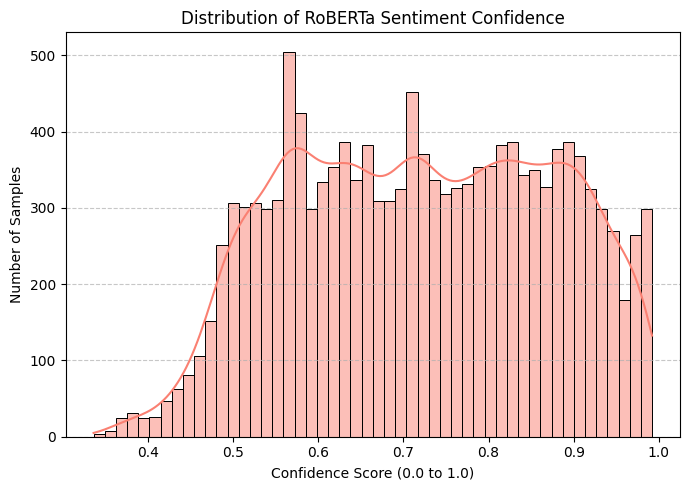

In [19]:
AUDIO_DIRECTORY = "dataset_meld/audio/"
AUDIO_EXT = ".wav"
splits = ['train', 'dev', 'test']

os.makedirs("dataset_meld", exist_ok=True)

# --- GLOBAL STATS (per split) ---
stats = defaultdict(int)
failed_samples = []

# Lists to collect data for final graphs
global_sentiment_scores = []

# --- PROCESSING LOOP ---
for split in splits:
    print(f"\n================ {split.upper()} SPLIT ================\n")

    orig_csv = os.path.join("dataset_meld", f"{split}_sent_emo.csv")
    out_csv = os.path.join("dataset_meld", f"prepared_{split}_{TIMESTAMP}_sent_emo.csv")

    print(f"Processing: {orig_csv}")
    df = pd.read_csv(orig_csv)

    # --- MOCK RUN MECHANISM ---
    MOCK_MODE = False  # Toggle this to False to run the full dataset
    if MOCK_MODE:
        # Take 10% of the data, sampled randomly
        df = df.sample(frac=0.10, random_state=SEED) 
        print(f"⚠️ MOCK MODE ACTIVE: Processing only 10% of {split} ({len(df)} samples)")
    # --------------------------

    prepared_data = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        dia_id = row['Dialogue_ID']
        utt_id = row['Utterance_ID']

        raw_path = os.path.join(
            AUDIO_DIRECTORY,
            f"wav_{split}",
            f"dia{dia_id}_utt{utt_id}{AUDIO_EXT}"
        )
        file_path = os.path.abspath(raw_path)

        # ---------------------------
        # Missing audio
        # ---------------------------
        if not os.path.exists(file_path):
            stats["missing_audio"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "missing_audio"
            })
            continue

        # ---------------------------
        # Validate CSV fields
        # ---------------------------
        if pd.isna(row['Emotion']) or pd.isna(row['Sentiment']) or pd.isna(row['Utterance']):
            stats["invalid_csv_data"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "invalid_csv_data"
            })
            continue

        emo_gt = str(row['Emotion']).lower()
        sent_gt = str(row['Sentiment']).lower()
        trans_gt = str(row['Utterance']).strip()

        # ---------------------------
        # Sentiment prediction (on ground-truth transcription)
        # ---------------------------
        try:
            bert_out = sentiment_classifier(trans_gt)[0]
            sent_pred = bert_out['label'].lower()
            sent_score = bert_out['score']

        except Exception as e:
            stats["sentiment_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "sentiment_failed", "error": str(e)
            })
            continue

        # ---------------------------
        # SUCCESS CASE
        # ---------------------------
        prepared_data.append({
            'emotion': emo_gt,
            'sentiment': sent_gt,  
            'textual_sentiment_predicted': sent_pred,
            'textual_sentiment_score': sent_score,
            'transcription_ground_truth': trans_gt,
            'file_path': file_path
        })

        stats["success"] += 1
        global_sentiment_scores.append(sent_score)

    # ---------------------------
    # Save entire batch at once (Optimised for GPU speed)
    # ---------------------------
    if prepared_data:
        chunk_df = pd.DataFrame(prepared_data)
        chunk_df.to_csv(out_csv, index=False)

    print(f"\n✅ Finished {split}. Saved to {out_csv}")
# ---------------------------
# FINAL REPORT
# ---------------------------
print("\n================ FINAL DATASET REPORT ================\n")

total_failures = (
    stats["missing_audio"] + stats["invalid_csv_data"] +
    stats["sentiment_failed"]
)

# Calculate Averages
avg_sent = sum(global_sentiment_scores) / len(global_sentiment_scores) if global_sentiment_scores else 0

print(f"Success samples           : {stats['success']}")
print(f"Missing audio             : {stats['missing_audio']}")
print(f"Invalid CSV data          : {stats['invalid_csv_data']}")
print(f"Sentiment prediction fail : {stats['sentiment_failed']}")
print(f"TOTAL FAILURES            : {total_failures}")
print("-" * 54)
print(f"Average Sentiment Score   : {avg_sent:.4f}")

# ---------------------------
# SAVE FAILURE LOG
# ---------------------------
failed_df = pd.DataFrame(failed_samples)
log_filename = f"dataset_meld/failed_samples_log_{TIMESTAMP}.csv"
failed_df.to_csv(log_filename, index=False)

print(f"\nFailure log saved: {log_filename}")

# ---------------------------
# GENERATE DISTRIBUTION GRAPH
# ---------------------------
if global_sentiment_scores:
    plt.figure(figsize=(7, 5))

    sns.histplot(global_sentiment_scores, bins=50, kde=True, color='salmon')
    plt.title("Distribution of RoBERTa Sentiment Confidence")
    plt.xlabel("Confidence Score (0.0 to 1.0)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

### 2.2 Acoustic Feature & 2.3 Statistical Features
MFCCs <br>
Chroma, contrast, zcr, rms

In [20]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
SR = 16000
MAX_DURATION = 3
MAX_SAMPLES = SR * MAX_DURATION
N_MFCC = 40
MAX_MFCC_LEN = 94 

csv_files = {
    'train': os.path.join(Config.DATA_PATH, f"prepared_train_{TIMESTAMP}_sent_emo.csv"),
    'dev': os.path.join(Config.DATA_PATH, f"prepared_dev_{TIMESTAMP}_sent_emo.csv"),
    'test': os.path.join(Config.DATA_PATH, f"prepared_test_{TIMESTAMP}_sent_emo.csv")
}

path = os.path.join(Config.DATA_PATH, f"all_features_{split}_{TIMESTAMP}.npz")

print(f"Starting Independent Feature Extraction to NPZ (Timestamp: {TIMESTAMP})...\n")

# ==========================================
# 2. EXTRACTION & SAVING LOOP (Per Split)
# ==========================================
for split, path in csv_files.items():
    if not os.path.exists(path):
        print(f"File not found: {path}")
        continue
        
    print(f"Processing {split.upper()} set from {path}")
    df = pd.read_csv(path)
    
    successful_rows = []
    mfcc_data = []
    stats_data = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        file_path = row['file_path']
        
        result, fail_reason = process_single_row(
            row, 
            clean_noise=best_preprocess_cfg['clean_noise'], 
            trim_silence=best_preprocess_cfg['trim_silence'], 
            aug_type=None  # Forced to 'None' based on our baseline decision
        )
        
        if result is None:
            continue
            
        mfcc, stats = result
        
        successful_rows.append(row)
        mfcc_data.append(mfcc.flatten())
        stats_data.append(stats)

    # ==========================================
    # 3. BUILD ARRAYS & SAVE FOR THIS SPLIT
    # ==========================================
    if successful_rows:
        print(f"Constructing NPZ archive for {split.upper()}...")
        
        # Convert the original rows back into a DataFrame to format them cleanly
        df_meta = pd.DataFrame(successful_rows).reset_index(drop=True)
        if 'split' not in df_meta.columns:
            df_meta.insert(0, 'split', split)
            
        out_npz = f"dataset_meld/all_features_{split}_{TIMESTAMP}.npz"
        print(f"Saving {split.upper()} to {out_npz}...")

        # Convert numerical lists to strict numpy arrays (float32 saves 50% memory)
        np_mfcc = np.array(mfcc_data, dtype=np.float32)
        np_stats = np.array(stats_data, dtype=np.float32)
        
        # Convert metadata to numpy structures
        np_meta = df_meta.to_numpy(dtype=str)
        meta_cols = df_meta.columns.to_numpy(dtype=str)

        # Save as a compressed NumPy archive
        np.savez_compressed(
            out_npz,
            mfcc=np_mfcc,
            stats=np_stats,
            meta=np_meta,
            meta_cols=meta_cols
        )
        print(f"{split.upper()} Matrix shapes -> Meta: {np_meta.shape}, MFCC: {np_mfcc.shape}, Stats: {np_stats.shape}\n")
    else:
        print(f"No valid samples extracted for {split.upper()}.\n")

    # ==========================================
    # 4. MEMORY CLEANUP
    # ==========================================
    del successful_rows, mfcc_data, stats_data, df_meta, np_mfcc, np_stats, np_meta
    gc.collect()

print("All splits processed and saved independently as NPZ archives!")

Starting Independent Feature Extraction to NPZ (Timestamp: 20260730_2205)...

Processing TRAIN set from dataset_meld/prepared_train_20260730_2205_sent_emo.csv


100%|██████████| 9988/9988 [01:45<00:00, 94.70it/s] 


Constructing NPZ archive for TRAIN...
Saving TRAIN to dataset_meld/all_features_train_20260730_2205.npz...
TRAIN Matrix shapes -> Meta: (9988, 7), MFCC: (9988, 3760), Stats: (9988, 21)

Processing DEV set from dataset_meld/prepared_dev_20260730_2205_sent_emo.csv


100%|██████████| 1108/1108 [00:10<00:00, 102.42it/s]


Constructing NPZ archive for DEV...
Saving DEV to dataset_meld/all_features_dev_20260730_2205.npz...
DEV Matrix shapes -> Meta: (1108, 7), MFCC: (1108, 3760), Stats: (1108, 21)

Processing TEST set from dataset_meld/prepared_test_20260730_2205_sent_emo.csv


100%|██████████| 2610/2610 [00:27<00:00, 94.72it/s] 


Constructing NPZ archive for TEST...
Saving TEST to dataset_meld/all_features_test_20260730_2205.npz...
TEST Matrix shapes -> Meta: (2610, 7), MFCC: (2610, 3760), Stats: (2610, 21)

All splits processed and saved independently as NPZ archives!


# 3.0 Load and Import (features and functions)

### Import NPZs (labels + acoustic features + textual sentiment predicted)

In [21]:
def load_and_prepare_npz(split, timestamp=TIMESTAMP):
    path = os.path.join(Config.DATA_PATH, f"all_features_{split}_{timestamp}.npz")
    data = np.load(path, allow_pickle=True)
    
    # Reshape MFCCs back to 2D sequence (Batch, TimeSteps, Features)
    X_mfcc = data['mfcc'].reshape(-1, Config.MAX_MFCC_LEN, Config.N_MFCC)
    X_stats = data['stats']
    
    meta_cols = data['meta_cols'].tolist()
    
    # Extract Target Labels (Emotion)
    emo_idx = meta_cols.index('emotion')
    y_raw = data['meta'][:, emo_idx]
    
    # Extract Textual Sentiment Predicted strings (Bimodal setup)
    pred_idx = meta_cols.index('textual_sentiment_predicted')
    X_text_pred_raw = data['meta'][:, pred_idx]
    
    return X_mfcc, X_stats, X_text_pred_raw, y_raw

print("Loading Data...")
X_train_mfcc, X_train_stats, X_train_txt_raw, y_train_raw = load_and_prepare_npz('train')
X_dev_mfcc, X_dev_stats, X_dev_txt_raw, y_dev_raw = load_and_prepare_npz('dev')
X_test_mfcc, X_test_stats, X_test_txt_raw, y_test_raw = load_and_prepare_npz('test')

# --- ENCODE TARGETS (Emotion) ---
label_encoder = LabelEncoder()
label_encoder.fit(Config.DEFAULT_CLASSES)

y_train = label_encoder.transform(y_train_raw)
y_dev = label_encoder.transform(y_dev_raw)
y_test = label_encoder.transform(y_test_raw)
num_classes = len(Config.DEFAULT_CLASSES)

# --- ENCODE TEXT MODALITY (Sentiment Predictions) ---
# OneHotEncoder transforms 'positive', 'neutral', 'negative' into 2D numerical vectors 
sentiment_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# We reshape to (-1, 1) because OneHotEncoder expects a 2D array matrix 
X_train_txt = sentiment_encoder.fit_transform(X_train_txt_raw.reshape(-1, 1))
X_dev_txt = sentiment_encoder.transform(X_dev_txt_raw.reshape(-1, 1))
X_test_txt = sentiment_encoder.transform(X_test_txt_raw.reshape(-1, 1))

scaler = StandardScaler()
X_train_stats = scaler.fit_transform(X_train_stats)
X_dev_stats = scaler.transform(X_dev_stats)
X_test_stats = scaler.transform(X_test_stats)

print(f"✅ Data Loaded & Encoded.")
print(f"Train MFCC Shape: {X_train_mfcc.shape}")
print(f"Train Stats Shape: {X_train_stats.shape}")
print(f"Train Text Modality Shape: {X_train_txt.shape} (One-Hot Encoded Sentiment)")

Loading Data...
✅ Data Loaded & Encoded.
Train MFCC Shape: (9988, 94, 40)
Train Stats Shape: (9988, 21)
Train Text Modality Shape: (9988, 3) (One-Hot Encoded Sentiment)


### Evaluation Functions

In [22]:
def plot_training_history(history, model_name):
    """Plots training/validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy Plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    axes[0].set_title(f'{model_name} - Model Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Loss Plot
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
    axes[1].set_title(f'{model_name} - Model Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def evaluate_model_performance(model, X_test, y_test, model_name):
    """Generates Classification Report and Percentage-based Confusion Matrix."""
    print(f"\n================ Evaluating {model_name} ================")
    
    # Predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # 1. Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))
    
    # 2. Confusion Matrix (Raw & Percentages)
    cm = confusion_matrix(y_test, y_pred)
    # Calculate percentages across rows (true labels)
    cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_percentages = np.nan_to_num(cm_percentages) # Handle division by zero
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percentages, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cbar_kws={'label': 'Percentage of True Class'})
    plt.title(f'{model_name} - Confusion Matrix (Percentages)')
    plt.ylabel('Ground Truth (True Label)')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Section 3. Train and Test

## CNN-LSTM Model (Training & Testing)

In [23]:
tf.keras.backend.clear_session()
gc.collect()
set_all_seeds(SEED)

# TRAIN
cnn_lstm_model = build_hybrid_cnn_lstm(num_classes, X_train_stats.shape[1], X_train_txt.shape[1])

print(f"Training for exactly {Config.EPOCHS} epochs...")
history_cnn_lstm = cnn_lstm_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,             
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),     
    epochs=Config.EPOCHS,
    batch_size=Config.BATCH_SIZE,
    verbose=1,
)

Training for exactly 50 epochs...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4838 - loss: 1.4762 - val_accuracy: 0.4774 - val_loss: 1.4784
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5102 - loss: 1.3977 - val_accuracy: 0.4756 - val_loss: 1.4797
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5168 - loss: 1.3818 - val_accuracy: 0.4747 - val_loss: 1.4782
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5211 - loss: 1.3753 - val_accuracy: 0.4774 - val_loss: 1.4833
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5212 - loss: 1.3679 - val_accuracy: 0.4747 - val_loss: 1.4822
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5259 - loss: 1.3633 - val_accuracy: 0.4756 - val_loss: 1.4812
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5247 - loss: 1.3582 - val_accuracy: 0.4702 - val_loss: 1.4849
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy

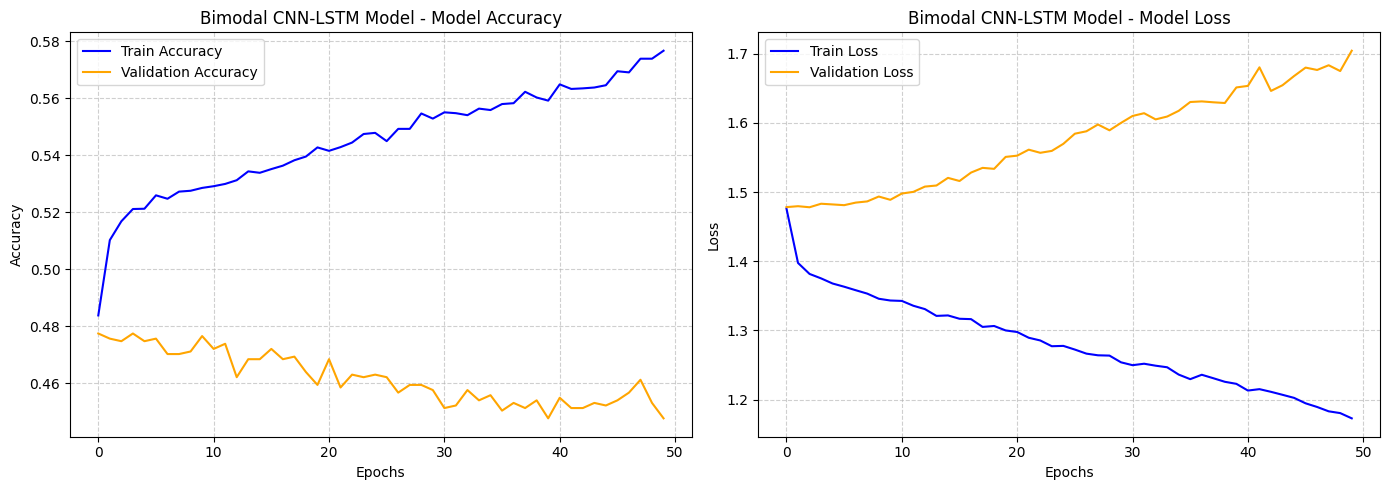


================ Evaluating Bimodal CNN-LSTM Model ================

--- Classification Report ---
              precision    recall  f1-score   support

       anger     0.2611    0.1710    0.2067       345
     disgust     0.1667    0.0147    0.0270        68
        fear     0.0000    0.0000    0.0000        50
         joy     0.4434    0.5647    0.4967       402
     neutral     0.5838    0.7850    0.6696      1256
     sadness     0.1688    0.0625    0.0912       208
    surprise     0.1625    0.0463    0.0720       281

    accuracy                         0.4977      2610
   macro avg     0.2552    0.2349    0.2233      2610
weighted avg     0.4190    0.4977    0.4418      2610



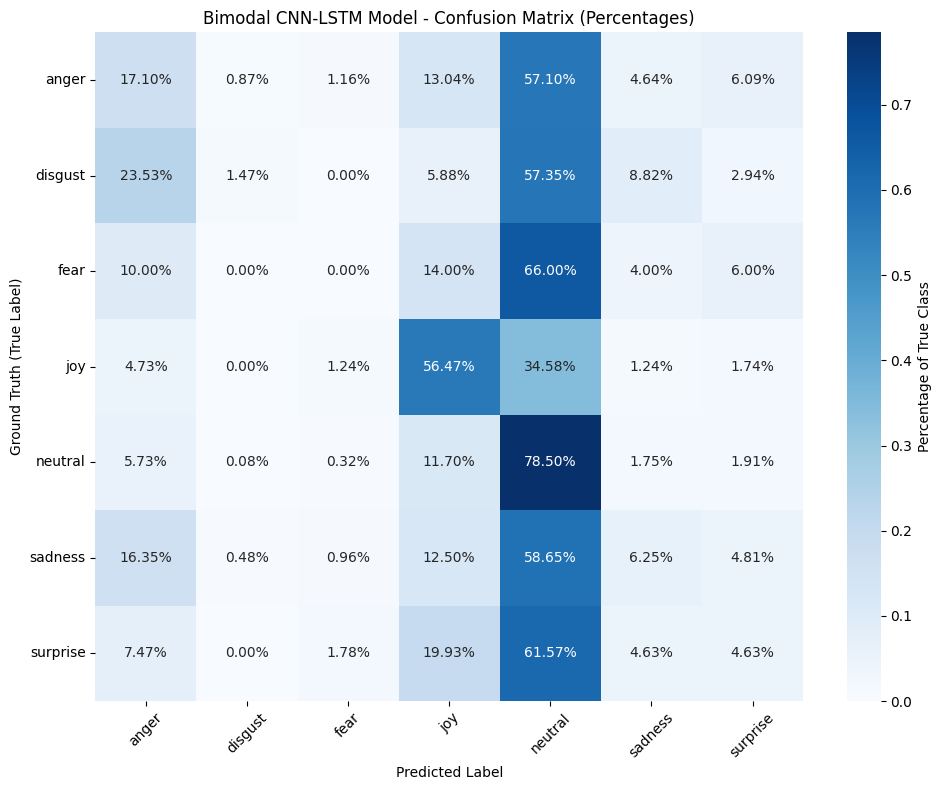

In [24]:
# ==========================================
# 4. EVALUATE
# ==========================================
plot_training_history(history_cnn_lstm, "Bimodal CNN-LSTM Model")
evaluate_model_performance(cnn_lstm_model, [X_test_mfcc, X_test_stats, X_test_txt], y_test, "Bimodal CNN-LSTM Model")


================ Evaluating Bimodal CNN-LSTM Model ================

--- Classification Report ---
              precision    recall  f1-score   support

       anger     0.2804    0.1961    0.2308       153
     disgust     0.0000    0.0000    0.0000        22
        fear     0.2000    0.0250    0.0444        40
         joy     0.3423    0.4663    0.3948       163
     neutral     0.5316    0.8081    0.6413       469
     sadness     0.3043    0.0631    0.1045       111
    surprise     0.0938    0.0200    0.0330       150

    accuracy                         0.4477      1108
   macro avg     0.2503    0.2255    0.2070      1108
weighted avg     0.3645    0.4477    0.3779      1108



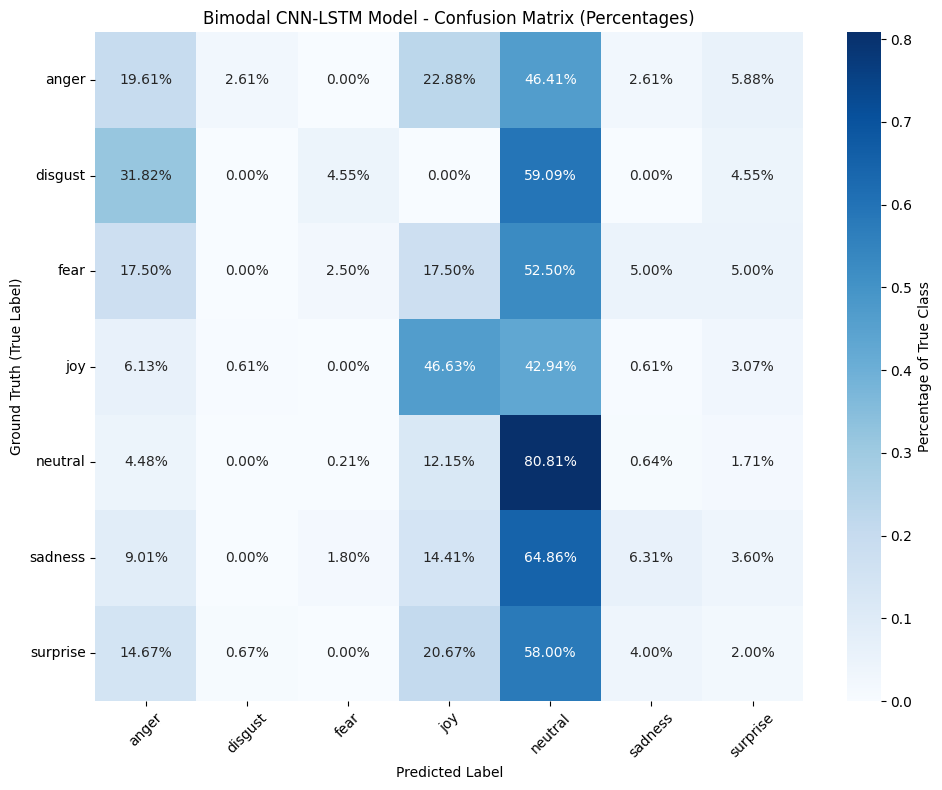

In [25]:
evaluate_model_performance(cnn_lstm_model, [X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev, "Bimodal CNN-LSTM Model")

### 1. Modality ablation — test the "text branch is doing all the work" hypothesis
Run inference three times, each time zeroing out one branch's input, and compare accuracy drop:

In [26]:
def eval_with_branch_masked(model, X_mfcc, X_stats, X_txt, y, mask_branch=None):
    Xm, Xs, Xt = X_mfcc.copy(), X_stats.copy(), X_txt.copy()
    if mask_branch == "mfcc":
        Xm[:] = 0
    elif mask_branch == "stats":
        Xs[:] = 0
    elif mask_branch == "text":
        Xt[:] = 0
    loss, acc = model.evaluate([Xm, Xs, Xt], y, verbose=0)
    return loss, acc

In [27]:
baseline_acc = cnn_lstm_model.evaluate([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev, verbose=0)[1]
loss_no_mfcc, acc_no_mfcc = eval_with_branch_masked(cnn_lstm_model, X_dev_mfcc, X_dev_stats, X_dev_txt, y_dev, "mfcc")
loss_no_stats, acc_no_stats = eval_with_branch_masked(cnn_lstm_model, X_dev_mfcc, X_dev_stats, X_dev_txt, y_dev, "stats")
loss_no_text, acc_no_text = eval_with_branch_masked(cnn_lstm_model, X_dev_mfcc, X_dev_stats, X_dev_txt, y_dev, "text")

print(f"Baseline (all branches):    Accuracy - {baseline_acc:.4f}, ")
print(f"Text branch zeroed:         Accuracy - {acc_no_text:.4f}  (drop = {baseline_acc-acc_no_text:.4f}), Loss - {loss_no_text:.4f}")
print(f"MFCC branch zeroed:         Accuracy - {acc_no_mfcc:.4f}  (drop = {baseline_acc-acc_no_mfcc:.4f}), Loss - {loss_no_mfcc:.4f}")
print(f"Stats branch zeroed:        Accuracy - {acc_no_stats:.4f}  (drop = {baseline_acc-acc_no_stats:.4f}), Loss - {loss_no_stats:.4f}")

Baseline (all branches):    Accuracy - 0.4477, 
Text branch zeroed:         Accuracy - 0.3818  (drop = 0.0659), Loss - 1.8606
MFCC branch zeroed:         Accuracy - 0.4143  (drop = 0.0334), Loss - 1.9140
Stats branch zeroed:        Accuracy - 0.4558  (drop = -0.0081), Loss - 1.7362


In [28]:
baseline_acc = cnn_lstm_model.evaluate([X_test_mfcc, X_test_stats, X_test_txt], y_test, verbose=0)[1]
loss_no_mfcc, acc_no_mfcc = eval_with_branch_masked(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, "mfcc")
loss_no_stats, acc_no_stats = eval_with_branch_masked(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, "stats")
loss_no_text, acc_no_text = eval_with_branch_masked(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, "text")

print(f"Baseline (all branches):    Accuracy - {baseline_acc:.4f}, ")
print(f"Text branch zeroed:         Accuracy - {acc_no_text:.4f}  (drop = {baseline_acc-acc_no_text:.4f}), Loss - {loss_no_text:.4f}")
print(f"MFCC branch zeroed:         Accuracy - {acc_no_mfcc:.4f}  (drop = {baseline_acc-acc_no_mfcc:.4f}), Loss - {loss_no_mfcc:.4f}")
print(f"Stats branch zeroed:        Accuracy - {acc_no_stats:.4f}  (drop = {baseline_acc-acc_no_stats:.4f}), Loss - {loss_no_stats:.4f}")

Baseline (all branches):    Accuracy - 0.4977, 
Text branch zeroed:         Accuracy - 0.4115  (drop = 0.0862), Loss - 1.7588
MFCC branch zeroed:         Accuracy - 0.4222  (drop = 0.0755), Loss - 1.8192
Stats branch zeroed:        Accuracy - 0.4877  (drop = 0.0100), Loss - 1.6465


### 2. Permutation importance (more rigorous than zeroing)
Zeroing can be an out-of-distribution input the model has never seen. Permutation (shuffling that branch's values across the batch) keeps the same distribution:

In [29]:
def permutation_importance(model, X_mfcc, X_stats, X_txt, y, branch, n_repeats=5, seed=SEED):
    np.random.seed(seed)
    baseline = model.evaluate([X_mfcc, X_stats, X_txt], y, verbose=0)[1]
    drops = []
    for _ in range(n_repeats):
        idx = np.random.permutation(len(y))
        Xm, Xs, Xt = X_mfcc.copy(), X_stats.copy(), X_txt.copy()
        if branch == "mfcc": Xm = Xm[idx]
        elif branch == "stats": Xs = Xs[idx]
        elif branch == "text": Xt = Xt[idx]
        acc = model.evaluate([Xm, Xs, Xt], y, verbose=0)[1]
        drops.append(baseline - acc)
    return np.mean(drops), np.std(drops)

for branch in ["mfcc", "stats", "text"]:
    mean_drop, std_drop = permutation_importance(cnn_lstm_model, X_dev_mfcc, X_dev_stats, X_dev_txt, y_dev, branch)
    print(f"{branch:6s}: mean accuracy drop = {mean_drop:.4f} ± {std_drop:.4f}")

mfcc  : mean accuracy drop = 0.0056 ± 0.0063
stats : mean accuracy drop = 0.0070 ± 0.0092
text  : mean accuracy drop = 0.1137 ± 0.0066


In [30]:
print("Stats feature means:", X_dev_stats.mean(axis=0)[:5])
print("Stats feature stds:", X_dev_stats.std(axis=0)[:5])

Stats feature means: [-0.02110404 -0.01856051 -0.04076465 -0.02415229 -0.0331783 ]
Stats feature stds: [1.0360055 1.037776  1.004158  1.0087947 1.0100425]


### 3. Investigate why stats contributes nothing 
— worth checking whether the stats features themselves carry emotion-relevant signal at all, independent of the model:

In [31]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf.fit(X_train_stats, y_train)
print("Stats-only RF dev accuracy:", rf.score(X_dev_stats, y_dev))

Stats-only RF dev accuracy: 0.4187725631768953


### 4. CONFUSION MATRIX: within-valence vs cross-valence error analysis

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
CLASSIFICATION REPORT (Dev Set)
              precision    recall  f1-score   support

       anger     0.2804    0.1961    0.2308       153
     disgust     0.0000    0.0000    0.0000        22
        fear     0.2000    0.0250    0.0444        40
         joy     0.3423    0.4663    0.3948       163
     neutral     0.5316    0.8081    0.6413       469
     sadness     0.3043    0.0631    0.1045       111
    surprise     0.0938    0.0200    0.0330       150

    accuracy                         0.4477      1108
   macro avg     0.2503    0.2255    0.2070      1108
weighted avg     0.3645    0.4477    0.3779      1108



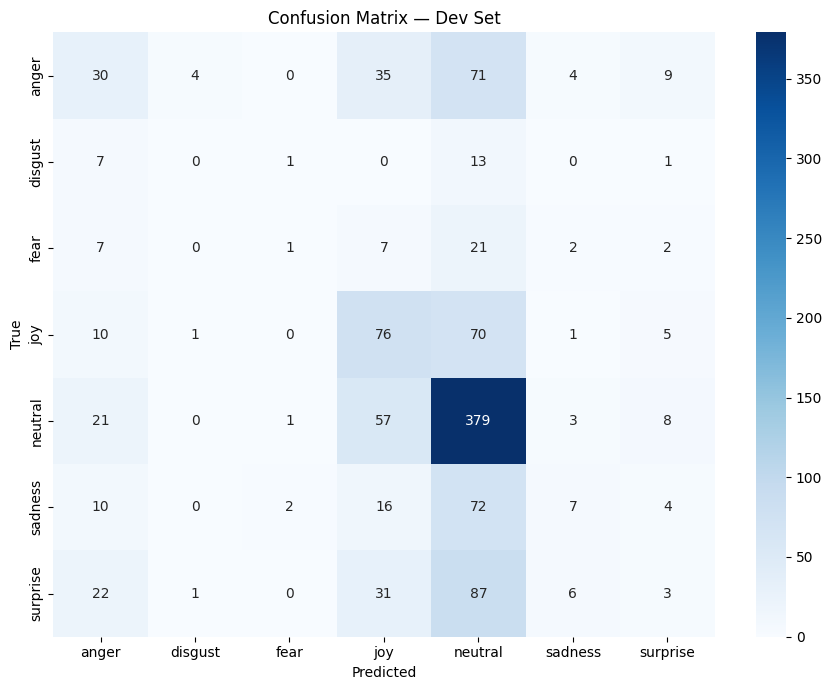


ERROR BREAKDOWN BY VALENCE
Correct predictions        : 496 (0.4477)
Within-valence errors      : 73 (0.0659)
Cross-valence errors       : 539 (0.4865)
Total errors               : 612

Of all errors, 11.9% stay within the same valence group


In [32]:
# ==========================================
# CONFUSION MATRIX: within-valence vs cross-valence error analysis
# ==========================================
# Define emotion label order (must match your label encoding, e.g., LabelEncoder classes_)
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

# Get model predictions on the dev set
y_pred_probs = cnn_lstm_model.predict([X_dev_mfcc, X_dev_stats, X_dev_txt])
y_pred = np.argmax(y_pred_probs, axis=1)

# Full classification report
print("=" * 60)
print("CLASSIFICATION REPORT (Dev Set)")
print("=" * 60)
print(classification_report(y_dev, y_pred, target_names=emotion_labels, digits=4))

# Confusion matrix
cm = confusion_matrix(y_dev, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title("Confusion Matrix — Dev Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ==========================================
# Group emotions into valence buckets and quantify within- vs cross-valence errors
# ==========================================
valence_map = {
    'joy': 'positive',
    'surprise': 'positive',      # surprise is ambiguous but often grouped positive in MELD's own sentiment mapping
    'neutral': 'neutral',
    'anger': 'negative',
    'disgust': 'negative',
    'fear': 'negative',
    'sadness': 'negative'
}

within_valence_errors = 0
cross_valence_errors = 0
correct = 0

for true_idx, pred_idx in zip(y_dev, y_pred):
    true_label = emotion_labels[true_idx]
    pred_label = emotion_labels[pred_idx]

    if true_label == pred_label:
        correct += 1
    elif valence_map[true_label] == valence_map[pred_label]:
        within_valence_errors += 1
    else:
        cross_valence_errors += 1

total = len(y_dev)
print("\n" + "=" * 60)
print("ERROR BREAKDOWN BY VALENCE")
print("=" * 60)
print(f"Correct predictions        : {correct} ({correct/total:.4f})")
print(f"Within-valence errors      : {within_valence_errors} ({within_valence_errors/total:.4f})")
print(f"Cross-valence errors       : {cross_valence_errors} ({cross_valence_errors/total:.4f})")
print(f"Total errors               : {within_valence_errors + cross_valence_errors}")
print(f"\nOf all errors, {within_valence_errors / (within_valence_errors + cross_valence_errors):.1%} stay within the same valence group")

### 5. Feature Sufficiency and Feature Necessity

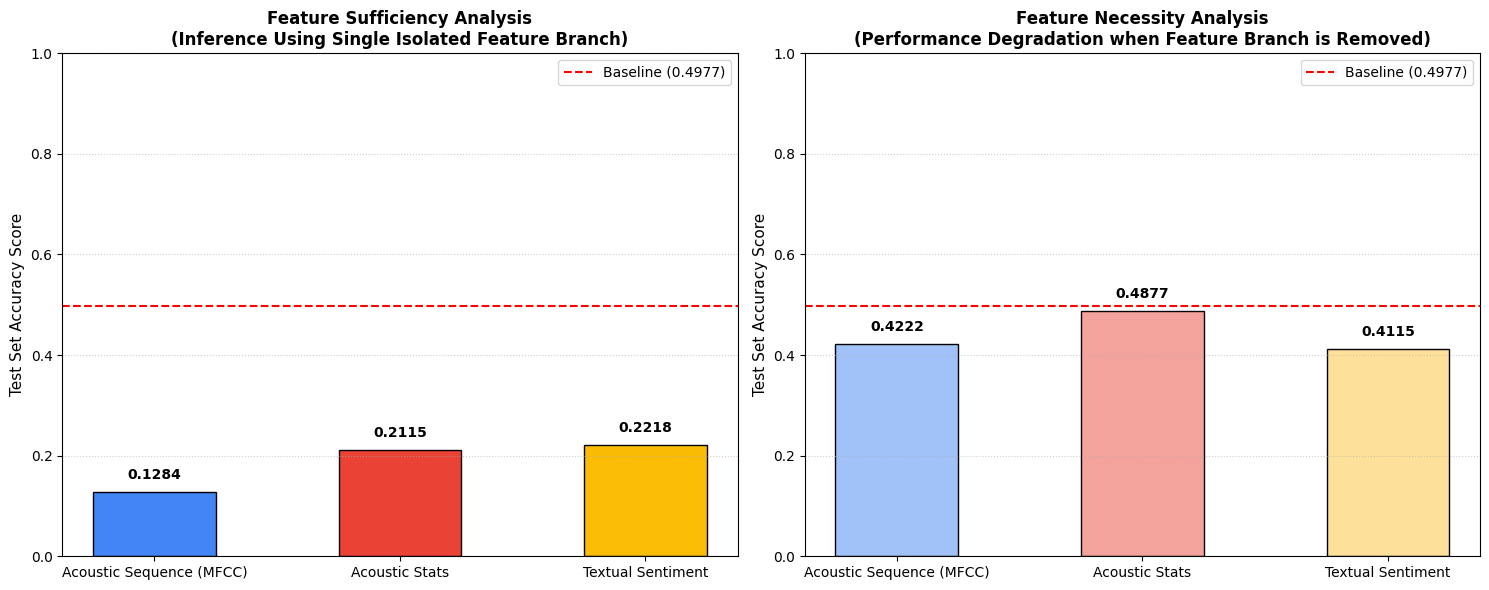

In [33]:
def evaluate_masked_accuracy(model, X_mfcc, X_stats, X_txt, y, mask_target=None):
    Xm, Xs, Xt = X_mfcc.copy(), X_stats.copy(), X_txt.copy()
    if mask_target == "mfcc":
        Xm[:] = 0.0
    elif mask_target == "stats":
        Xs[:] = 0.0
    elif mask_target == "text":
        Xt[:] = 0.0
    
    loss, acc = model.evaluate([Xm, Xs, Xt], y, verbose=0)
    return acc

baseline_test_acc = cnn_lstm_model.evaluate([X_test_mfcc, X_test_stats, X_test_txt], y_test, verbose=0)[1]

# 1. Feature Sufficiency Evaluation (Individual modalities active)
sufficiency_scores = {
    "Acoustic Sequence (MFCC)": evaluate_masked_accuracy(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, mask_target="none"), # Handled via baseline logic definition
    "Acoustic Stats": evaluate_masked_accuracy(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, mask_target="none"),
    "Textual Sentiment": evaluate_masked_accuracy(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, mask_target="none")
}

# Explicitly isolate each single modality condition
suff_mfcc = evaluate_masked_accuracy(cnn_lstm_model, X_test_mfcc, np.zeros_like(X_test_stats), np.zeros_like(X_test_txt), y_test, mask_target=None)
suff_stats = evaluate_masked_accuracy(cnn_lstm_model, np.zeros_like(X_test_mfcc), X_test_stats, np.zeros_like(X_test_txt), y_test, mask_target=None)
suff_text = evaluate_masked_accuracy(cnn_lstm_model, np.zeros_like(X_test_mfcc), np.zeros_like(X_test_stats), X_test_txt, y_test, mask_target=None)

# 2. Feature Necessity Evaluation (Individual modalities completely zeroed out)
nec_no_mfcc = evaluate_masked_accuracy(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, mask_target="mfcc")
nec_no_stats = evaluate_masked_accuracy(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, mask_target="stats")
nec_no_text = evaluate_masked_accuracy(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, mask_target="text")

# --- PLOTTING DATA GENERATION ---
modalities = ["Acoustic Sequence (MFCC)", "Acoustic Stats", "Textual Sentiment"]
sufficiency_values = [suff_mfcc, suff_stats, suff_text]
necessity_values = [nec_no_mfcc, nec_no_stats, nec_no_text]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graph A: Feature Sufficiency
bars1 = ax1.bar(modalities, sufficiency_values, color=['#4285F4', '#EA4335', '#FBBC05'], edgecolor='black', width=0.5)
ax1.axhline(baseline_test_acc, color='red', linestyle='--', label=f'Baseline ({baseline_test_acc:.4f})')
ax1.set_title("Feature Sufficiency Analysis\n(Inference Using Single Isolated Feature Branch)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Test Set Accuracy Score", fontsize=11)
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

# Graph B: Feature Necessity
bars2 = ax2.bar(modalities, necessity_values, color=['#A0C2F9', '#F3A39C', '#FDE09A'], edgecolor='black', width=0.5)
ax2.axhline(baseline_test_acc, color='red', linestyle='--', label=f'Baseline ({baseline_test_acc:.4f})')
ax2.set_title("Feature Necessity Analysis\n(Performance Degradation when Feature Branch is Removed)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Test Set Accuracy Score", fontsize=11)
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

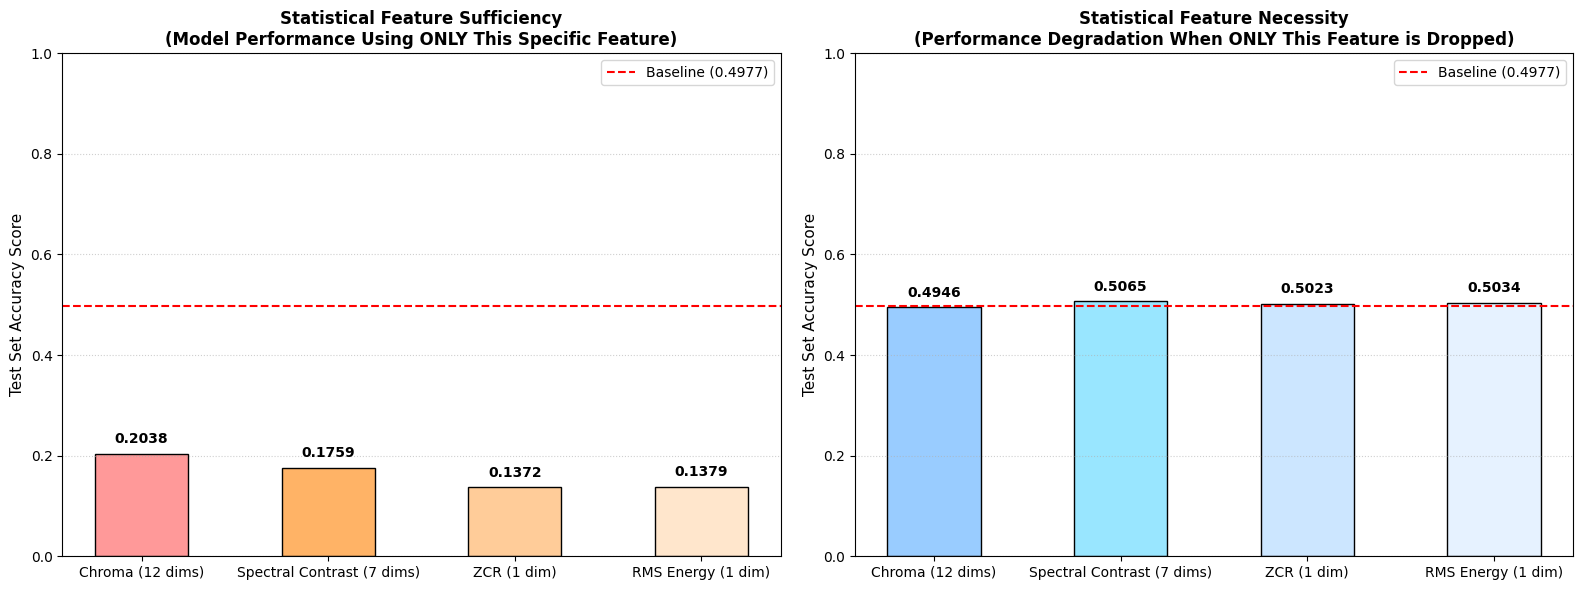

In [34]:
# 1. Map the exact column indices for the Statistical Features (Total: 21 dims)
stat_feature_slices = {
    "Chroma (12 dims)": slice(0, 12),
    "Spectral Contrast (7 dims)": slice(12, 19),
    "ZCR (1 dim)": slice(19, 20),
    "RMS Energy (1 dim)": slice(20, 21)
}

def evaluate_detailed_stats(model, X_mfcc, X_stats, X_txt, y, target_feature, mode):
    """
    mode='sufficiency': Zeros out MFCC, Text, and all other stats EXCEPT the target.
    mode='necessity': Keeps everything active, but zeros out ONLY the target stat.
    """
    Xm, Xs, Xt = X_mfcc.copy(), X_stats.copy(), X_txt.copy()
    
    if mode == "sufficiency":
        # Turn off other main modalities completely
        Xm[:] = 0.0
        Xt[:] = 0.0
        
        # Create a blank stats array, then copy over ONLY the targeted statistical feature
        Xs_isolated = np.zeros_like(Xs)
        Xs_isolated[:, stat_feature_slices[target_feature]] = Xs[:, stat_feature_slices[target_feature]]
        Xs = Xs_isolated
        
    elif mode == "necessity":
        # Keep the joint model entirely active, just blind the model to this specific stat
        Xs[:, stat_feature_slices[target_feature]] = 0.0
        
    loss, acc = model.evaluate([Xm, Xs, Xt], y, verbose=0)
    return acc

# Calculate Baseline performance using the trained BAN model on the test dataset
baseline_test_acc = cnn_lstm_model.evaluate([X_test_mfcc, X_test_stats, X_test_txt], y_test, verbose=0)[1]

# 2. Compute Sufficiency and Necessity for each individual statistical feature
stat_features = list(stat_feature_slices.keys())
sufficiency_values = []
necessity_values = []

for feature in stat_features:
    suff_acc = evaluate_detailed_stats(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, feature, mode="sufficiency")
    nec_acc = evaluate_detailed_stats(cnn_lstm_model, X_test_mfcc, X_test_stats, X_test_txt, y_test, feature, mode="necessity")
    
    sufficiency_values.append(suff_acc)
    necessity_values.append(nec_acc)

# --- 3. PLOTTING DATA GENERATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_suff = ['#FF9999', '#FFB366', '#FFCC99', '#FFE6CC']
colors_nec = ['#99CCFF', '#99E6FF', '#CCE6FF', '#E6F2FF']

# Graph A: Individual Feature Sufficiency
bars1 = ax1.bar(stat_features, sufficiency_values, color=colors_suff, edgecolor='black', width=0.5)
ax1.axhline(baseline_test_acc, color='red', linestyle='--', label=f'Baseline ({baseline_test_acc:.4f})')
ax1.set_title("Statistical Feature Sufficiency\n(Model Performance Using ONLY This Specific Feature)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Test Set Accuracy Score", fontsize=11)
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=10)

# Graph B: Individual Feature Necessity
bars2 = ax2.bar(stat_features, necessity_values, color=colors_nec, edgecolor='black', width=0.5)
ax2.axhline(baseline_test_acc, color='red', linestyle='--', label=f'Baseline ({baseline_test_acc:.4f})')
ax2.set_title("Statistical Feature Necessity\n(Performance Degradation When ONLY This Feature is Dropped)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Test Set Accuracy Score", fontsize=11)
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 6. Ablation Study on Class Configuration

In [35]:
# Container for matching experiment rows
ablation_rows = []
per_class_matrix_rows = [] 
unique_test_labels = label_encoder.classes_

print("Starting Multi-Class Ablation Loop using Hybrid CNN-LSTM architecture layout...")

# --- 1. RUN BASELINE CONFIGURATION ---
print("\n[Experiment 0] running Baseline Joint Configuration (All 7 Classes)...")
y_pred_probs_base = cnn_lstm_model.predict([X_test_mfcc, X_test_stats, X_test_txt], verbose=0)
y_pred_base = np.argmax(y_pred_probs_base, axis=1)

base_report = classification_report(y_test, y_pred_base, target_names=unique_test_labels, output_dict=True, digits=4)

ablation_rows.append({
    "Dropped Class": "None (Baseline)",
    "Test Accuracy": base_report["accuracy"],
    "Macro Precision": base_report["macro avg"]["precision"],
    "Macro Recall": base_report["macro avg"]["recall"],
    "Macro F1-Score": base_report["macro avg"]["f1-score"]
})

# extract per-class recall and F1 for the baseline row
base_row_recall = {"Dropped Class": "None (Baseline)"}
base_row_f1 = {"Dropped Class": "None (Baseline)"}
for cls in unique_test_labels:
    base_row_recall[cls] = base_report[cls]["recall"]
    base_row_f1[f"{cls} (F1)"] = base_report[cls]["f1-score"]
per_class_matrix_rows.append({**base_row_recall, **base_row_f1})

# --- 2. LOOP TO DROPPED SINGLE CLASSES ---
for idx, target_drop_cls in enumerate(unique_test_labels):
    print(f"\n[Experiment {idx+1}/7] Evaluated Performance Excluding Class: '{target_drop_cls}'")
    
    # Calculate index mapping value
    encoded_drop_idx = label_encoder.transform([target_drop_cls])[0]
    
    # Isolate training segments
    train_mask = (y_train != encoded_drop_idx)
    dev_mask = (y_dev != encoded_drop_idx)
    test_mask = (y_test != encoded_drop_idx)
    
    # Subset target structures matching filter metrics
    X_tr_m, X_tr_s, X_tr_t, y_tr = X_train_mfcc[train_mask], X_train_stats[train_mask], X_train_txt[train_mask], y_train[train_mask]
    X_dv_m, X_dv_s, X_dv_t, y_dv = X_dev_mfcc[dev_mask], X_dev_stats[dev_mask], X_dev_txt[dev_mask], y_dev[dev_mask]
    X_ts_m, X_ts_s, X_ts_t, y_ts = X_test_mfcc[test_mask], X_test_stats[test_mask], X_test_txt[test_mask], y_test[test_mask]
    
    # Compute new subset balanced weights weights
    sub_cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    sub_cw_dict = {cls: weight for cls, weight in zip(np.unique(y_tr), sub_cw)}
    
    # Instantiate new model architecture matching 7 class projection space layout
    tf.keras.backend.clear_session()
    set_all_seeds(SEED)
    ablation_model = build_hybrid_cnn_lstm(num_classes=len(Config.DEFAULT_CLASSES), stats_dim=X_tr_s.shape[1], sent_dim=X_tr_t.shape[1])
    
    # Train alternative classification space
    ablation_model.fit(
        [X_tr_m, X_tr_s, X_tr_t], y_tr,
        validation_data=([X_dv_m, X_dv_s, X_dv_t], y_dv),
        epochs=Config.EPOCHS, batch_size=Config.BATCH_SIZE, verbose=1
    )
    
    # Generate prediction bounds
    y_pred_probs = ablation_model.predict([X_ts_m, X_ts_s, X_ts_t], verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Form conditional subset names list for evaluation report
    active_class_names = [cls for cls in unique_test_labels if cls != target_drop_cls]
    
    # Build localized metrics framework dictionary
    rep = classification_report(y_ts, y_pred, labels=np.unique(y_tr), target_names=active_class_names, output_dict=True, digits=4)
    
    ablation_rows.append({
        "Dropped Class": f"Excluding {target_drop_cls}",
        "Test Accuracy": rep["accuracy"],
        "Macro Precision": rep["macro avg"]["precision"],
        "Macro Recall": rep["macro avg"]["recall"],
        "Macro F1-Score": rep["macro avg"]["f1-score"]
    })

    # extract per-class recall and F1, leaving the dropped class blank (not 0.0)
    row_recall = {"Dropped Class": f"Excluding {target_drop_cls}"}
    row_f1 = {"Dropped Class": f"Excluding {target_drop_cls}"}
    for cls in unique_test_labels:
        if cls == target_drop_cls:
            row_recall[cls] = np.nan          # class wasn't in this run at all — NaN, not 0
            row_f1[f"{cls} (F1)"] = np.nan
        else:
            row_recall[cls] = rep[cls]["recall"]
            row_f1[f"{cls} (F1)"] = rep[cls]["f1-score"]
    per_class_matrix_rows.append({**row_recall, **row_f1})
    
    del ablation_model; gc.collect()

# --- 3. DISPLAY FINAL PERFORMANCE FRAMEWORK TABLE ---
df_class_ablation_report = pd.DataFrame(ablation_rows)
print("\n" + "="*30 + " CLASS ABLATION COMPARISON REPORT " + "="*30)
display(df_class_ablation_report.style.highlight_max(subset=["Test Accuracy", "Macro F1-Score"], color="darkred").format(precision=4))

# --- 4. NEW: DISPLAY PER-CLASS RECALL/F1 MATRIX ---
df_per_class_ablation = pd.DataFrame(per_class_matrix_rows).set_index("Dropped Class")
print("\n" + "="*30 + " PER-CLASS RECALL/F1 MATRIX (Class Ablation) " + "="*30)
display(df_per_class_ablation.style.format(precision=4, na_rep="—"))

Starting Multi-Class Ablation Loop using Hybrid CNN-LSTM architecture layout...

[Experiment 0] running Baseline Joint Configuration (All 7 Classes)...

[Experiment 1/7] Evaluated Performance Excluding Class: 'anger'
Epoch 1/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5424 - loss: 1.3061 - val_accuracy: 0.5309 - val_loss: 1.2775
Epoch 2/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5671 - loss: 1.2131 - val_accuracy: 0.5351 - val_loss: 1.2716
Epoch 3/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5693 - loss: 1.1970 - val_accuracy: 0.5330 - val_loss: 1.2811
Epoch 4/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5725 - loss: 1.1856 - val_accuracy: 0.5403 - val_loss: 1.2670
Epoch 5/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5763 - loss: 1.1782 - val_accuracy: 0.5361 - val_loss: 1.2723
Epoch 6/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5777 - loss: 1.1772 - val_accuracy: 0.5330 - val_loss: 1.2654
Epoch 7/5

,Dropped Class,Test Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,None (Baseline),0.4977,0.2552,0.2349,0.2233
1,Excluding anger,0.5682,0.2607,0.2617,0.2504
2,Excluding disgust,0.5130,0.2840,0.2764,0.2670
3,Excluding fear,0.5086,0.2979,0.2797,0.2756
4,Excluding joy,0.5571,0.2312,0.2142,0.2101
5,Excluding neutral,0.4328,0.2959,0.2994,0.2900
6,Excluding sadness,0.5525,0.2680,0.2636,0.2538
7,Excluding surprise,0.5706,0.2859,0.2720,0.2699



============================== PER-CLASS RECALL/F1 MATRIX (Class Ablation) ==============================


,anger,disgust,fear,joy,neutral,sadness,surprise,anger (F1),disgust (F1),fear (F1),joy (F1),neutral (F1),sadness (F1),surprise (F1)
Dropped Class,,,,,,,,,,,,,,
None (Baseline),0.1710,0.0147,0.0000,0.5647,0.7850,0.0625,0.0463,0.2067,0.0270,0.0000,0.4967,0.6696,0.0912,0.0720
Excluding anger,—,0.0000,0.0000,0.5597,0.8081,0.1346,0.0676,—,0.0000,0.0000,0.5131,0.7201,0.1647,0.1044
Excluding disgust,0.1623,—,0.0000,0.5572,0.7850,0.0721,0.0819,0.2146,—,0.0000,0.4912,0.6840,0.0997,0.1127
Excluding fear,0.1942,0.0000,—,0.5000,0.7866,0.1298,0.0676,0.2450,0.0000,—,0.4664,0.6730,0.1709,0.0984
Excluding joy,0.2029,0.0000,0.0000,—,0.8854,0.1010,0.0961,0.2555,0.0000,0.0000,—,0.7406,0.1395,0.1253
Excluding neutral,0.3159,0.0294,0.0200,0.7363,—,0.2356,0.4591,0.3597,0.0370,0.0308,0.6366,—,0.2707,0.4050
Excluding sadness,0.1913,0.0000,0.0000,0.5149,0.8288,—,0.0463,0.2435,0.0000,0.0000,0.4952,0.7111,—,0.0730
Excluding surprise,0.2058,0.0000,0.0000,0.5124,0.8225,0.0913,—,0.2582,0.0000,0.0000,0.5131,0.7196,0.1284,—


## BAN Model (Training & Testing)

In [36]:
set_all_seeds(SEED)
# TRAIN
ban_model = build_ban(num_classes, X_train_stats.shape[1], X_train_txt.shape[1])

print(f"Training BAN for exactly {Config.EPOCHS} epochs...")
history_ban = ban_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,  
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),
    epochs=Config.EPOCHS,
    batch_size=Config.BATCH_SIZE,
    verbose=1
)

Training BAN for exactly 50 epochs...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4975 - loss: 1.4332 - val_accuracy: 0.4756 - val_loss: 1.4884
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5116 - loss: 1.3860 - val_accuracy: 0.4838 - val_loss: 1.4856
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5182 - loss: 1.3776 - val_accuracy: 0.4838 - val_loss: 1.4892
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5173 - loss: 1.3693 - val_accuracy: 0.4810 - val_loss: 1.4826
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5232 - loss: 1.3633 - val_accuracy: 0.4810 - val_loss: 1.4869
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5257 - loss: 1.3567 - val_accuracy: 0.4856 - val_loss: 1.4865
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5258 - loss: 1.3514 - val_accuracy: 0.4819 - val_loss: 1.4957
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accur

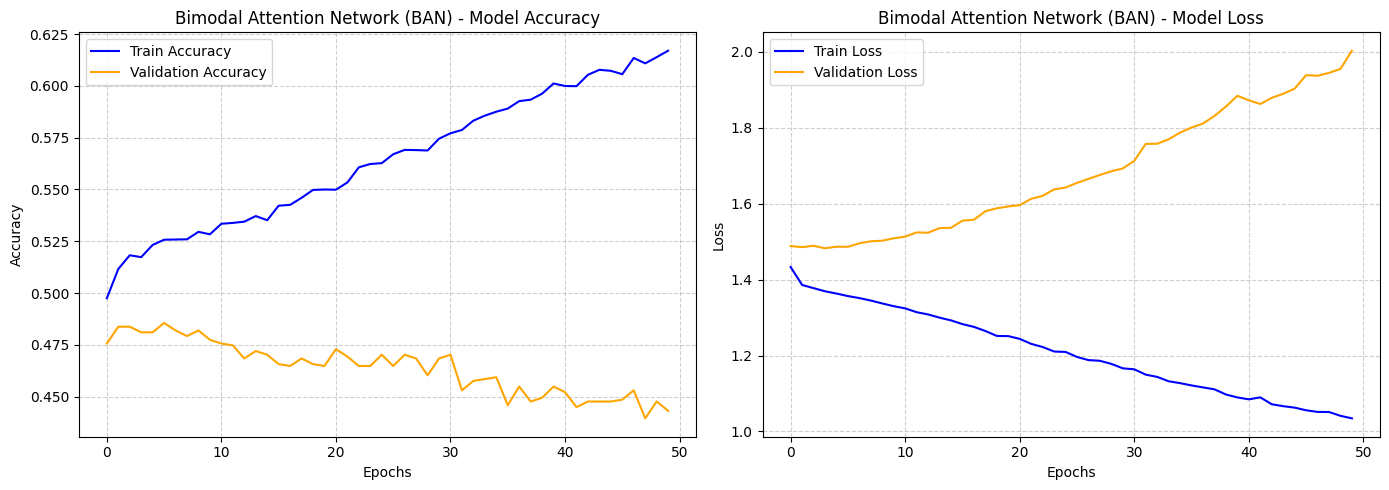


================ Evaluating Bimodal Attention Network (BAN) ================

--- Classification Report ---
              precision    recall  f1-score   support

       anger     0.3014    0.1913    0.2340       345
     disgust     0.0000    0.0000    0.0000        68
        fear     0.0476    0.0200    0.0282        50
         joy     0.4313    0.5547    0.4853       402
     neutral     0.5985    0.7715    0.6741      1256
     sadness     0.1158    0.0529    0.0726       208
    surprise     0.1240    0.0534    0.0746       281

    accuracy                         0.4923      2610
   macro avg     0.2312    0.2348    0.2241      2610
weighted avg     0.4178    0.4923    0.4444      2610



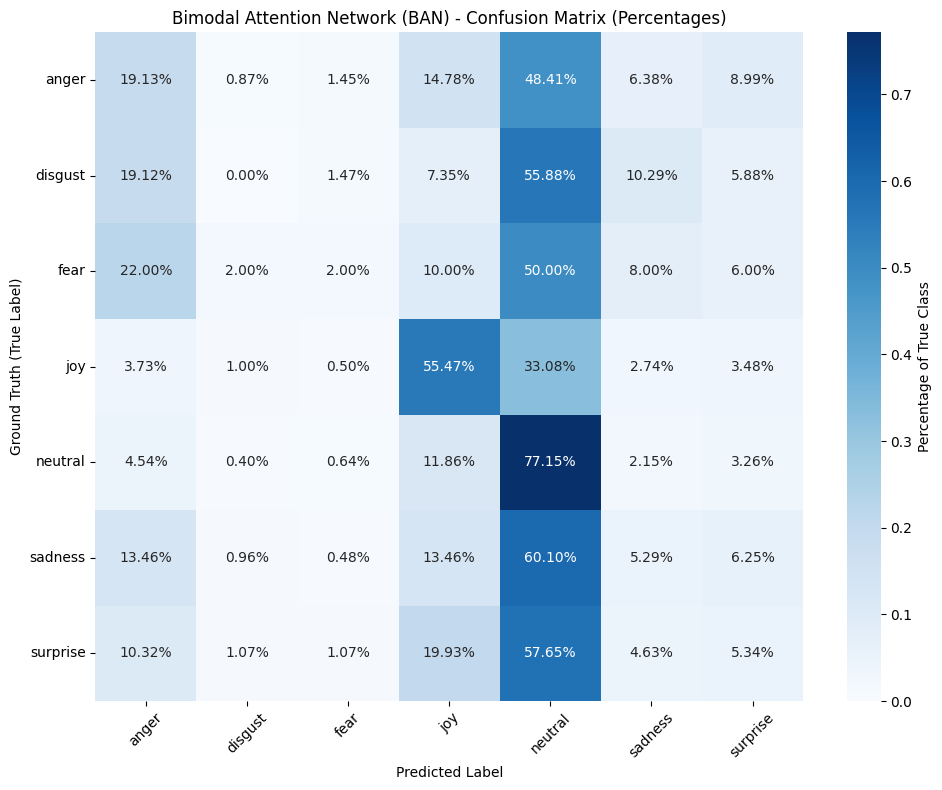

In [37]:
# ==========================================
# 5. EVALUATE
# ==========================================
plot_training_history(history_ban, "Bimodal Attention Network (BAN)")
evaluate_model_performance(ban_model, [X_test_mfcc, X_test_stats, X_test_txt], y_test, "Bimodal Attention Network (BAN)")


================ Evaluating Bimodal Attention Network (BAN) ================

--- Classification Report ---
              precision    recall  f1-score   support

       anger     0.3070    0.2288    0.2622       153
     disgust     0.0909    0.0455    0.0606        22
        fear     0.0000    0.0000    0.0000        40
         joy     0.3380    0.4417    0.3830       163
     neutral     0.5446    0.7804    0.6415       469
     sadness     0.3333    0.0901    0.1418       111
    surprise     0.1228    0.0467    0.0676       150

    accuracy                         0.4431      1108
   macro avg     0.2481    0.2333    0.2224      1108
weighted avg     0.3745    0.4431    0.3887      1108



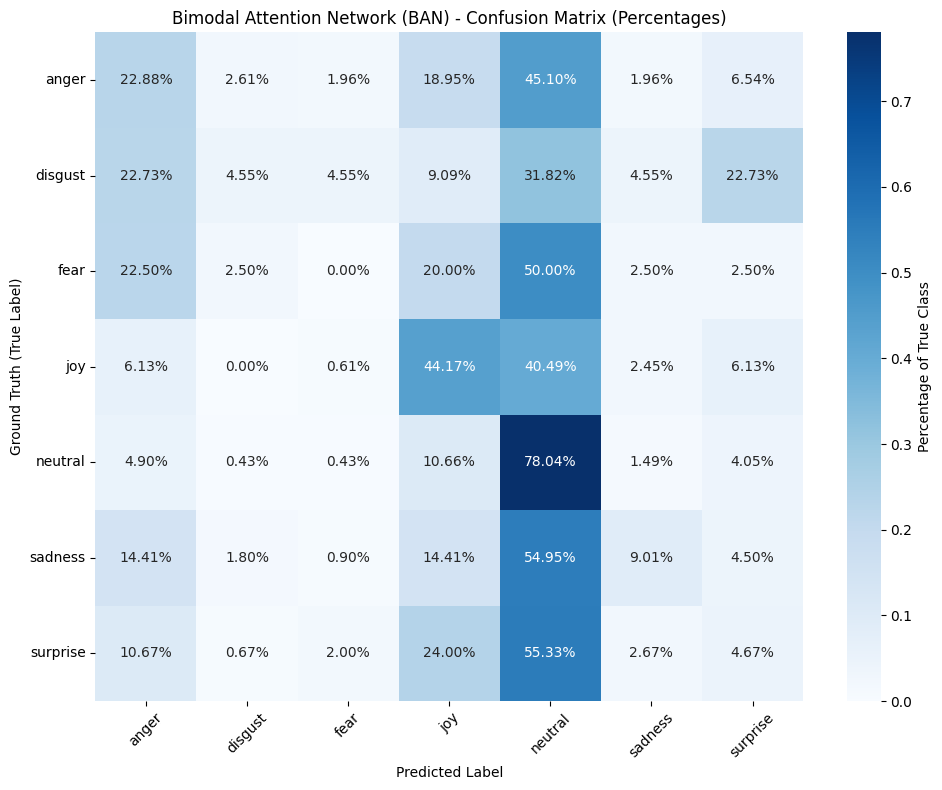

In [38]:
evaluate_model_performance(ban_model, [X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev, "Bimodal Attention Network (BAN)")

### 1. Baseline

In [39]:
print("Starting BAN Component Ablation Study...")
ban_component_results = []

# =========================================================================
# EXPERIMENT 1: BASELINE BAN (GATED ATTENTION)
# =========================================================================
print("\n[Experiment 1] Training Baseline BAN...")
tf.keras.backend.clear_session()
gc.collect()
set_all_seeds(SEED)

# Build Baseline Model
base_model = build_ban(num_classes=len(Config.DEFAULT_CLASSES), 
                       stats_dim=X_train_stats.shape[1], 
                       sent_dim=X_train_txt.shape[1])

# Train Baseline
base_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),
    epochs=Config.EPOCHS, 
    batch_size=Config.BATCH_SIZE, 
    verbose=0
)

# Predict & Evaluate
y_pred_base = np.argmax(base_model.predict([X_test_mfcc, X_test_stats, X_test_txt], verbose=0), axis=1)

print("\n--- Classification Report (Baseline BAN) ---")
print(classification_report(y_test, y_pred_base, target_names=Config.DEFAULT_CLASSES, digits=4))

rep_base = classification_report(y_test, y_pred_base, target_names=Config.DEFAULT_CLASSES, digits=4, output_dict=True)
ban_component_results.append({
    "Experiment": "Baseline BAN (Gated Attention)",
    "Accuracy": rep_base["accuracy"],
    "Macro Precision": rep_base["macro avg"]["precision"],
    "Macro Recall": rep_base["macro avg"]["recall"],
    "Macro F1-Score": rep_base["macro avg"]["f1-score"]
})

Starting BAN Component Ablation Study...

[Experiment 1] Training Baseline BAN...

--- Classification Report (Baseline BAN) ---
              precision    recall  f1-score   support

     neutral     0.3014    0.1913    0.2340       345
         joy     0.0000    0.0000    0.0000        68
     sadness     0.0476    0.0200    0.0282        50
       anger     0.4313    0.5547    0.4853       402
        fear     0.5985    0.7715    0.6741      1256
     disgust     0.1158    0.0529    0.0726       208
    surprise     0.1240    0.0534    0.0746       281

    accuracy                         0.4923      2610
   macro avg     0.2312    0.2348    0.2241      2610
weighted avg     0.4178    0.4923    0.4444      2610



### 2. No Attention
The `Multiply()` attention layer is completely removed. Acoustic and textual projections are simply concatenated.

In [40]:
# =========================================================================
# EXPERIMENT 2: NO ATTENTION BAN
# =========================================================================
print("\n[Experiment 2] Training No Attention BAN...")
tf.keras.backend.clear_session()
gc.collect()

def build_ban_no_attention(num_classes, stats_dim, sent_dim):
    in_mfcc = layers.Input(shape=(Config.MAX_MFCC_LEN, Config.N_MFCC), name="in_mfcc")
    x_mfcc = layers.Conv1D(64, 3, activation='relu', padding='same')(in_mfcc)
    x_mfcc = layers.MaxPooling1D(2)(x_mfcc)
    x_mfcc = layers.LSTM(64)(x_mfcc)

    in_stats = layers.Input(shape=(stats_dim,), name="in_stats")
    x_stats = layers.Dense(32, activation='relu')(in_stats)
    x_stats = layers.BatchNormalization()(x_stats)

    x_audio_combined = layers.Concatenate()([x_mfcc, x_stats])
    x_audio_proj = layers.Dense(64, activation='relu')(x_audio_combined)

    in_text = layers.Input(shape=(sent_dim,), name="in_text")
    x_text = layers.Dense(64, activation='relu')(in_text)

    # Bypass attention scaling -> Direct Concatenation
    merged = layers.Concatenate()([x_audio_proj, x_text])
    x = layers.Dense(128, activation='relu')(merged)
    x = layers.Dropout(Config.DROPOUT)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=[in_mfcc, in_stats, in_text], outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

set_all_seeds(SEED)
no_att_model = build_ban_no_attention(num_classes=len(Config.DEFAULT_CLASSES), stats_dim=X_train_stats.shape[1], sent_dim=X_train_txt.shape[1])

no_att_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),
    epochs=Config.EPOCHS, batch_size=Config.BATCH_SIZE, verbose=0
)

y_pred_no_att = np.argmax(no_att_model.predict([X_test_mfcc, X_test_stats, X_test_txt], verbose=0), axis=1)

print("\n--- Classification Report (No Attention BAN) ---")
print(classification_report(y_test, y_pred_no_att, target_names=Config.DEFAULT_CLASSES, digits=4))

rep_no_att = classification_report(y_test, y_pred_no_att, target_names=Config.DEFAULT_CLASSES, digits=4, output_dict=True)
ban_component_results.append({
    "Experiment": "No Attention BAN (Simple Fusion)",
    "Accuracy": rep_no_att["accuracy"],
    "Macro Precision": rep_no_att["macro avg"]["precision"],
    "Macro Recall": rep_no_att["macro avg"]["recall"],
    "Macro F1-Score": rep_no_att["macro avg"]["f1-score"]
})


[Experiment 2] Training No Attention BAN...

--- Classification Report (No Attention BAN) ---
              precision    recall  f1-score   support

     neutral     0.2849    0.1420    0.1896       345
         joy     0.0000    0.0000    0.0000        68
     sadness     0.0556    0.0200    0.0294        50
       anger     0.4314    0.5398    0.4796       402
        fear     0.5817    0.7795    0.6662      1256
     disgust     0.1316    0.0481    0.0704       208
    surprise     0.1824    0.0961    0.1259       281

    accuracy                         0.4916      2610
   macro avg     0.2382    0.2322    0.2230      2610
weighted avg     0.4152    0.4916    0.4392      2610



### 3. Cross-Modal Attention
Uses `tf.keras.layers.Attention`. The acoustic features act as the *Query* to extract relevant context from the textual *Value*.

In [41]:
# =========================================================================
# EXPERIMENT 3: CROSS-MODAL ATTENTION BAN
# =========================================================================
print("\n[Experiment 3] Training Cross-Modal Attention BAN...")
tf.keras.backend.clear_session()
gc.collect()

def build_ban_cross_modal(num_classes, stats_dim, sent_dim):
    in_mfcc = layers.Input(shape=(Config.MAX_MFCC_LEN, Config.N_MFCC), name="in_mfcc")
    x_mfcc = layers.Conv1D(64, 3, activation='relu', padding='same')(in_mfcc)
    x_mfcc = layers.MaxPooling1D(2)(x_mfcc)
    x_mfcc = layers.LSTM(64)(x_mfcc)

    in_stats = layers.Input(shape=(stats_dim,), name="in_stats")
    x_stats = layers.Dense(32, activation='relu')(in_stats)
    x_stats = layers.BatchNormalization()(x_stats)

    x_audio_combined = layers.Concatenate()([x_mfcc, x_stats])
    x_audio_proj = layers.Dense(64, activation='relu')(x_audio_combined)

    in_text = layers.Input(shape=(sent_dim,), name="in_text")
    x_text = layers.Dense(64, activation='relu')(in_text)

    # Reshape for Keras Attention Layer (Requires 3D tensors: batch, steps, features)
    audio_reshaped = layers.Reshape((1, 64))(x_audio_proj)
    text_reshaped = layers.Reshape((1, 64))(x_text)

    # Formal Scaled Dot-Product Attention
    cross_attention_out = layers.Attention()([audio_reshaped, text_reshaped])
    cross_attention_flat = layers.Flatten()(cross_attention_out)

    merged = layers.Concatenate()([cross_attention_flat, x_audio_proj, x_text])
    x = layers.Dense(128, activation='relu')(merged)
    x = layers.Dropout(Config.DROPOUT)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=[in_mfcc, in_stats, in_text], outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

set_all_seeds(SEED)
cross_att_model = build_ban_cross_modal(num_classes=len(Config.DEFAULT_CLASSES), stats_dim=X_train_stats.shape[1], sent_dim=X_train_txt.shape[1])

cross_att_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),
    epochs=Config.EPOCHS, batch_size=Config.BATCH_SIZE, verbose=0
)

y_pred_cross = np.argmax(cross_att_model.predict([X_test_mfcc, X_test_stats, X_test_txt], verbose=0), axis=1)

print("\n--- Classification Report (Cross-Modal Attention BAN) ---")
print(classification_report(y_test, y_pred_cross, target_names=Config.DEFAULT_CLASSES, digits=4))

rep_cross = classification_report(y_test, y_pred_cross, target_names=Config.DEFAULT_CLASSES, digits=4, output_dict=True)
ban_component_results.append({
    "Experiment": "Cross-Modal BAN (Scaled Dot-Product)",
    "Accuracy": rep_cross["accuracy"],
    "Macro Precision": rep_cross["macro avg"]["precision"],
    "Macro Recall": rep_cross["macro avg"]["recall"],
    "Macro F1-Score": rep_cross["macro avg"]["f1-score"]
})


[Experiment 3] Training Cross-Modal Attention BAN...


c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(



--- Classification Report (Cross-Modal Attention BAN) ---
              precision    recall  f1-score   support

     neutral     0.2907    0.1913    0.2308       345
         joy     0.0000    0.0000    0.0000        68
     sadness     0.0417    0.0200    0.0270        50
       anger     0.4105    0.5075    0.4538       402
        fear     0.5885    0.7651    0.6653      1256
     disgust     0.1325    0.0529    0.0756       208
    surprise     0.0942    0.0463    0.0621       281

    accuracy                         0.4812      2610
   macro avg     0.2226    0.2261    0.2164      2610
weighted avg     0.4064    0.4812    0.4338      2610



### 4. Textual Sentiment Masking
The text inputs in the test set are explicitly zeroed out. Predictions are run using the previously trained Baseline BAN model.

In [42]:
# =========================================================================
# EXPERIMENT 4: TEXTUAL MASKING INFERENCE
# =========================================================================
print("\n[Experiment 4] Evaluating Baseline BAN with Masked Text...")

# Zero out the text modality for the test set
X_test_text_masked = np.zeros_like(X_test_txt)

# Predict using the base_model from Experiment 1
y_pred_masked = np.argmax(base_model.predict([X_test_mfcc, X_test_stats, X_test_text_masked], verbose=0), axis=1)

print("\n--- Classification Report (Masked Text BAN) ---")
print(classification_report(y_test, y_pred_masked, target_names=Config.DEFAULT_CLASSES, digits=4))

rep_masked = classification_report(y_test, y_pred_masked, target_names=Config.DEFAULT_CLASSES, digits=4, output_dict=True)
ban_component_results.append({
    "Experiment": "Masked Text BAN (Zeroed Text Branch)",
    "Accuracy": rep_masked["accuracy"],
    "Macro Precision": rep_masked["macro avg"]["precision"],
    "Macro Recall": rep_masked["macro avg"]["recall"],
    "Macro F1-Score": rep_masked["macro avg"]["f1-score"]
})


[Experiment 4] Evaluating Baseline BAN with Masked Text...

--- Classification Report (Masked Text BAN) ---
              precision    recall  f1-score   support

     neutral     0.2570    0.1333    0.1756       345
         joy     0.0000    0.0000    0.0000        68
     sadness     0.0541    0.0400    0.0460        50
       anger     0.1865    0.1716    0.1788       402
        fear     0.5182    0.7014    0.5961      1256
     disgust     0.0789    0.0288    0.0423       208
    surprise     0.1086    0.0854    0.0956       281

    accuracy                         0.3939      2610
   macro avg     0.1719    0.1658    0.1620      2610
weighted avg     0.3311    0.3939    0.3521      2610



### 5. Expanded Acoustic Kernel
Broaden the receptive field of the initial 1D-Convolution layer by expanding the kernel size from `3` to `7`.

In [43]:
# =========================================================================
# EXPERIMENT 5: LARGE KERNEL BAN
# =========================================================================
print("\n[Experiment 5] Training Large Kernel BAN...")
tf.keras.backend.clear_session()
gc.collect()

def build_ban_large_kernel(num_classes, stats_dim, sent_dim):
    in_mfcc = layers.Input(shape=(Config.MAX_MFCC_LEN, Config.N_MFCC), name="in_mfcc")
    # Shift kernel size from 3 to 7
    x_mfcc = layers.Conv1D(64, 7, activation='relu', padding='same')(in_mfcc)
    x_mfcc = layers.MaxPooling1D(2)(x_mfcc)
    x_mfcc = layers.LSTM(64)(x_mfcc)

    in_stats = layers.Input(shape=(stats_dim,), name="in_stats")
    x_stats = layers.Dense(32, activation='relu')(in_stats)
    x_stats = layers.BatchNormalization()(x_stats)

    x_audio_combined = layers.Concatenate()([x_mfcc, x_stats])
    x_audio_proj = layers.Dense(64, activation='relu')(x_audio_combined)

    in_text = layers.Input(shape=(sent_dim,), name="in_text")
    x_text = layers.Dense(64, activation='relu')(in_text)

    attention_weights = layers.Dense(64, activation='sigmoid', name="text_guided_attention")(x_text)
    attended_audio = layers.Multiply(name="attended_audio")([x_audio_proj, attention_weights])

    merged = layers.Concatenate()([attended_audio, x_text])
    x = layers.Dense(128, activation='relu')(merged)
    x = layers.Dropout(Config.DROPOUT)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=[in_mfcc, in_stats, in_text], outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

set_all_seeds(SEED)
large_kernel_model = build_ban_large_kernel(num_classes=len(Config.DEFAULT_CLASSES), stats_dim=X_train_stats.shape[1], sent_dim=X_train_txt.shape[1])

large_kernel_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),
    epochs=Config.EPOCHS, batch_size=Config.BATCH_SIZE, verbose=0
)

y_pred_kernel = np.argmax(large_kernel_model.predict([X_test_mfcc, X_test_stats, X_test_txt], verbose=0), axis=1)

print("\n--- Classification Report (Large Kernel BAN) ---")
print(classification_report(y_test, y_pred_kernel, target_names=Config.DEFAULT_CLASSES, digits=4))

rep_kernel = classification_report(y_test, y_pred_kernel, target_names=Config.DEFAULT_CLASSES, digits=4, output_dict=True)
ban_component_results.append({
    "Experiment": "Large Kernel BAN (Conv1D size=7)",
    "Accuracy": rep_kernel["accuracy"],
    "Macro Precision": rep_kernel["macro avg"]["precision"],
    "Macro Recall": rep_kernel["macro avg"]["recall"],
    "Macro F1-Score": rep_kernel["macro avg"]["f1-score"]
})


[Experiment 5] Training Large Kernel BAN...

--- Classification Report (Large Kernel BAN) ---
              precision    recall  f1-score   support

     neutral     0.2982    0.1971    0.2373       345
         joy     0.0500    0.0147    0.0227        68
     sadness     0.0690    0.0400    0.0506        50
       anger     0.4072    0.5348    0.4624       402
        fear     0.5955    0.7747    0.6734      1256
     disgust     0.1622    0.0577    0.0851       208
    surprise     0.1134    0.0391    0.0582       281

    accuracy                         0.4912      2610
   macro avg     0.2422    0.2369    0.2271      2610
weighted avg     0.4165    0.4912    0.4412      2610



### Summary

In [44]:
# =========================================================================
# SUMMARY MATRIX OUTPUT
# =========================================================================
df_component_ablation = pd.DataFrame(ban_component_results)

print("\n" + "="*30 + " BAN COMPONENT ABLATION SUMMARY " + "="*30)
display(df_component_ablation.style.set_properties(**{'text-align': 'center'}).highlight_max(subset=["Accuracy", "Macro F1-Score"], color="darkred").format(precision=4))


============================== BAN COMPONENT ABLATION SUMMARY ==============================


,Experiment,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,Baseline BAN (Gated Attention),0.4923,0.2312,0.2348,0.2241
1,No Attention BAN (Simple Fusion),0.4916,0.2382,0.2322,0.2230
2,Cross-Modal BAN (Scaled Dot-Product),0.4812,0.2226,0.2261,0.2164
3,Masked Text BAN (Zeroed Text Branch),0.3939,0.1719,0.1658,0.1620
4,Large Kernel BAN (Conv1D size=7),0.4912,0.2422,0.2369,0.2271
